<a href="https://colab.research.google.com/github/BREIMER606/Programaci-n-Cient-fica/blob/main/Lab1_Pct.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SCIENTIFIC COMPUTING – Lab_1

Breimer Meneses

The preprocessing module is responsible for loading the raw CSV file, removing rows with missing values in mandatory columns, selecting the relevant IMU columns, and applying a moving‑average filter implemented with simple OOP classes. This prepares the accelerometer signals for visualization and downstream analysis.

In [ ]:
# =========  LOADING AND SAVING =========

def load_data(csv_path: str) -> pd.DataFrame:
    """
    Load a CSV file into a pandas DataFrame.

    Complexity: reading N rows is O(N) in the number of samples.
    """
    return pd.read_csv(csv_path)   # Complexity: O(N)


def save_csv(df: pd.DataFrame, output_path: str) -> None:
    """
    Save a DataFrame to CSV.

    Complexity: writing N rows is O(N).
    """
    df.to_csv(output_path, index=False)   # Complexity: O(N)


# =========  CLEANING AND COLUMN SELECTION =========

def clean_nan(df: pd.DataFrame, required_columns: list) -> pd.DataFrame:
    """
    Drop rows with NaN in specific columns.

    Complexity: O(N * K), where N is number of rows and K the number of required columns.
    """
    return df.dropna(subset=required_columns)   # Complexity: O(N * K)


def select_columns(df: pd.DataFrame, columns: list) -> pd.DataFrame:
    """
    Select a subset of columns.

    Complexity: O(N * K), where K is the number of selected columns.
    """
    return df[columns].copy()   # Complexity: O(N * K)


# =========  OBJECT‑ORIENTED MOVING‑AVERAGE FILTER =========

class SensorSignal:
    """
    Base class representing a generic sensor signal.
    Only stores references to time and values.

    Complexity: constructor is O(1); evaluate() is defined in subclasses.
    """
    def __init__(self, time, values, name):
        self.time = time              # O(1)
        self.values = values          # O(1)
        self.name = name              # O(1)

    def evaluate(self):
        raise NotImplementedError("Implement in subclasses.")


class OriginalSignal(SensorSignal):
    """Represents the unfiltered signal."""

    def evaluate(self):
        """
        Return the original values.

        Complexity: O(1) (no computation, just a reference).
        """
        return self.values            # O(1)


class FilteredSignal(SensorSignal):
    """Signal filtered using a moving‑average window."""

    def __init__(self, time, values, name, window_size=10):
        super().__init__(time, values, name)
        self.window_size = window_size    # O(1)

    def evaluate(self):
        """
        Apply a moving‑average filter using a cumulative sum.

        Complexity: O(N), where N is the length of the signal.
        """
        cumsum = np.cumsum(np.insert(self.values, 0, 0))                  # O(N)
        filtered = (cumsum[self.window_size:] - cumsum[:-self.window_size]) / self.window_size  # O(N)

        filtered_full = np.full_like(self.values, np.nan)                # O(N)
        filtered_full[self.window_size - 1:] = filtered                  # O(N)
        return filtered_full


def apply_moving_average_filter(df: pd.DataFrame,
                                columns: list,
                                time_column: str,
                                window_size: int = 50):
    """
    Apply the moving‑average filter to several columns using OOP.

    Returns a dictionary with original and filtered signals.

    Complexity: O(N * K), where N is number of rows and K is number of filtered columns.
    """
    time = df[time_column].values              # O(N)
    results = {}

    for col in columns:                        # Loop over K columns
        original = OriginalSignal(time, df[col].values, f"{col}_original")     # O(1)
        filtered = FilteredSignal(time, df[col].values, f"{col}_filtered", window_size)  # O(1)

        results[col] = {
            "original": original.evaluate(),   # O(N)
            "filtered": filtered.evaluate(),   # O(N)
            "time": time                       # O(1) (shared reference)
        }

    return results                             # Overall O(N * K)


def save_filter_figures(results: dict,
                        figures_folder: str,
                        max_samples: int = 1000) -> None:
    """
    Generate and save comparison plots between original and filtered signals.

    Complexity: O(M * S), where M is number of variables in 'results'
    and S is the number of plotted samples (capped by max_samples).
    """
    os.makedirs(figures_folder, exist_ok=True)       # O(1)

    for col, data in results.items():                # Loop over M variables
        time = data["time"][:max_samples]            # O(S)
        original = data["original"][:max_samples]    # O(S)
        filtered = data["filtered"][:max_samples]    # O(S)

        plt.figure(figsize=(10, 5))                  # O(1)
        plt.plot(time, original, label="Original", alpha=0.5)   # O(S)
        plt.plot(time, filtered, label="Filtered", linewidth=2) # O(S)
        plt.title(f"Signal {col}: Original vs Filtered")
        plt.xlabel("Time")
        plt.ylabel(col)
        plt.grid()
        plt.legend()

        path = os.path.join(figures_folder, f"{col}_comparison.png")
        plt.savefig(path, dpi=300)                   # O(S) drawing cost
        plt.close()


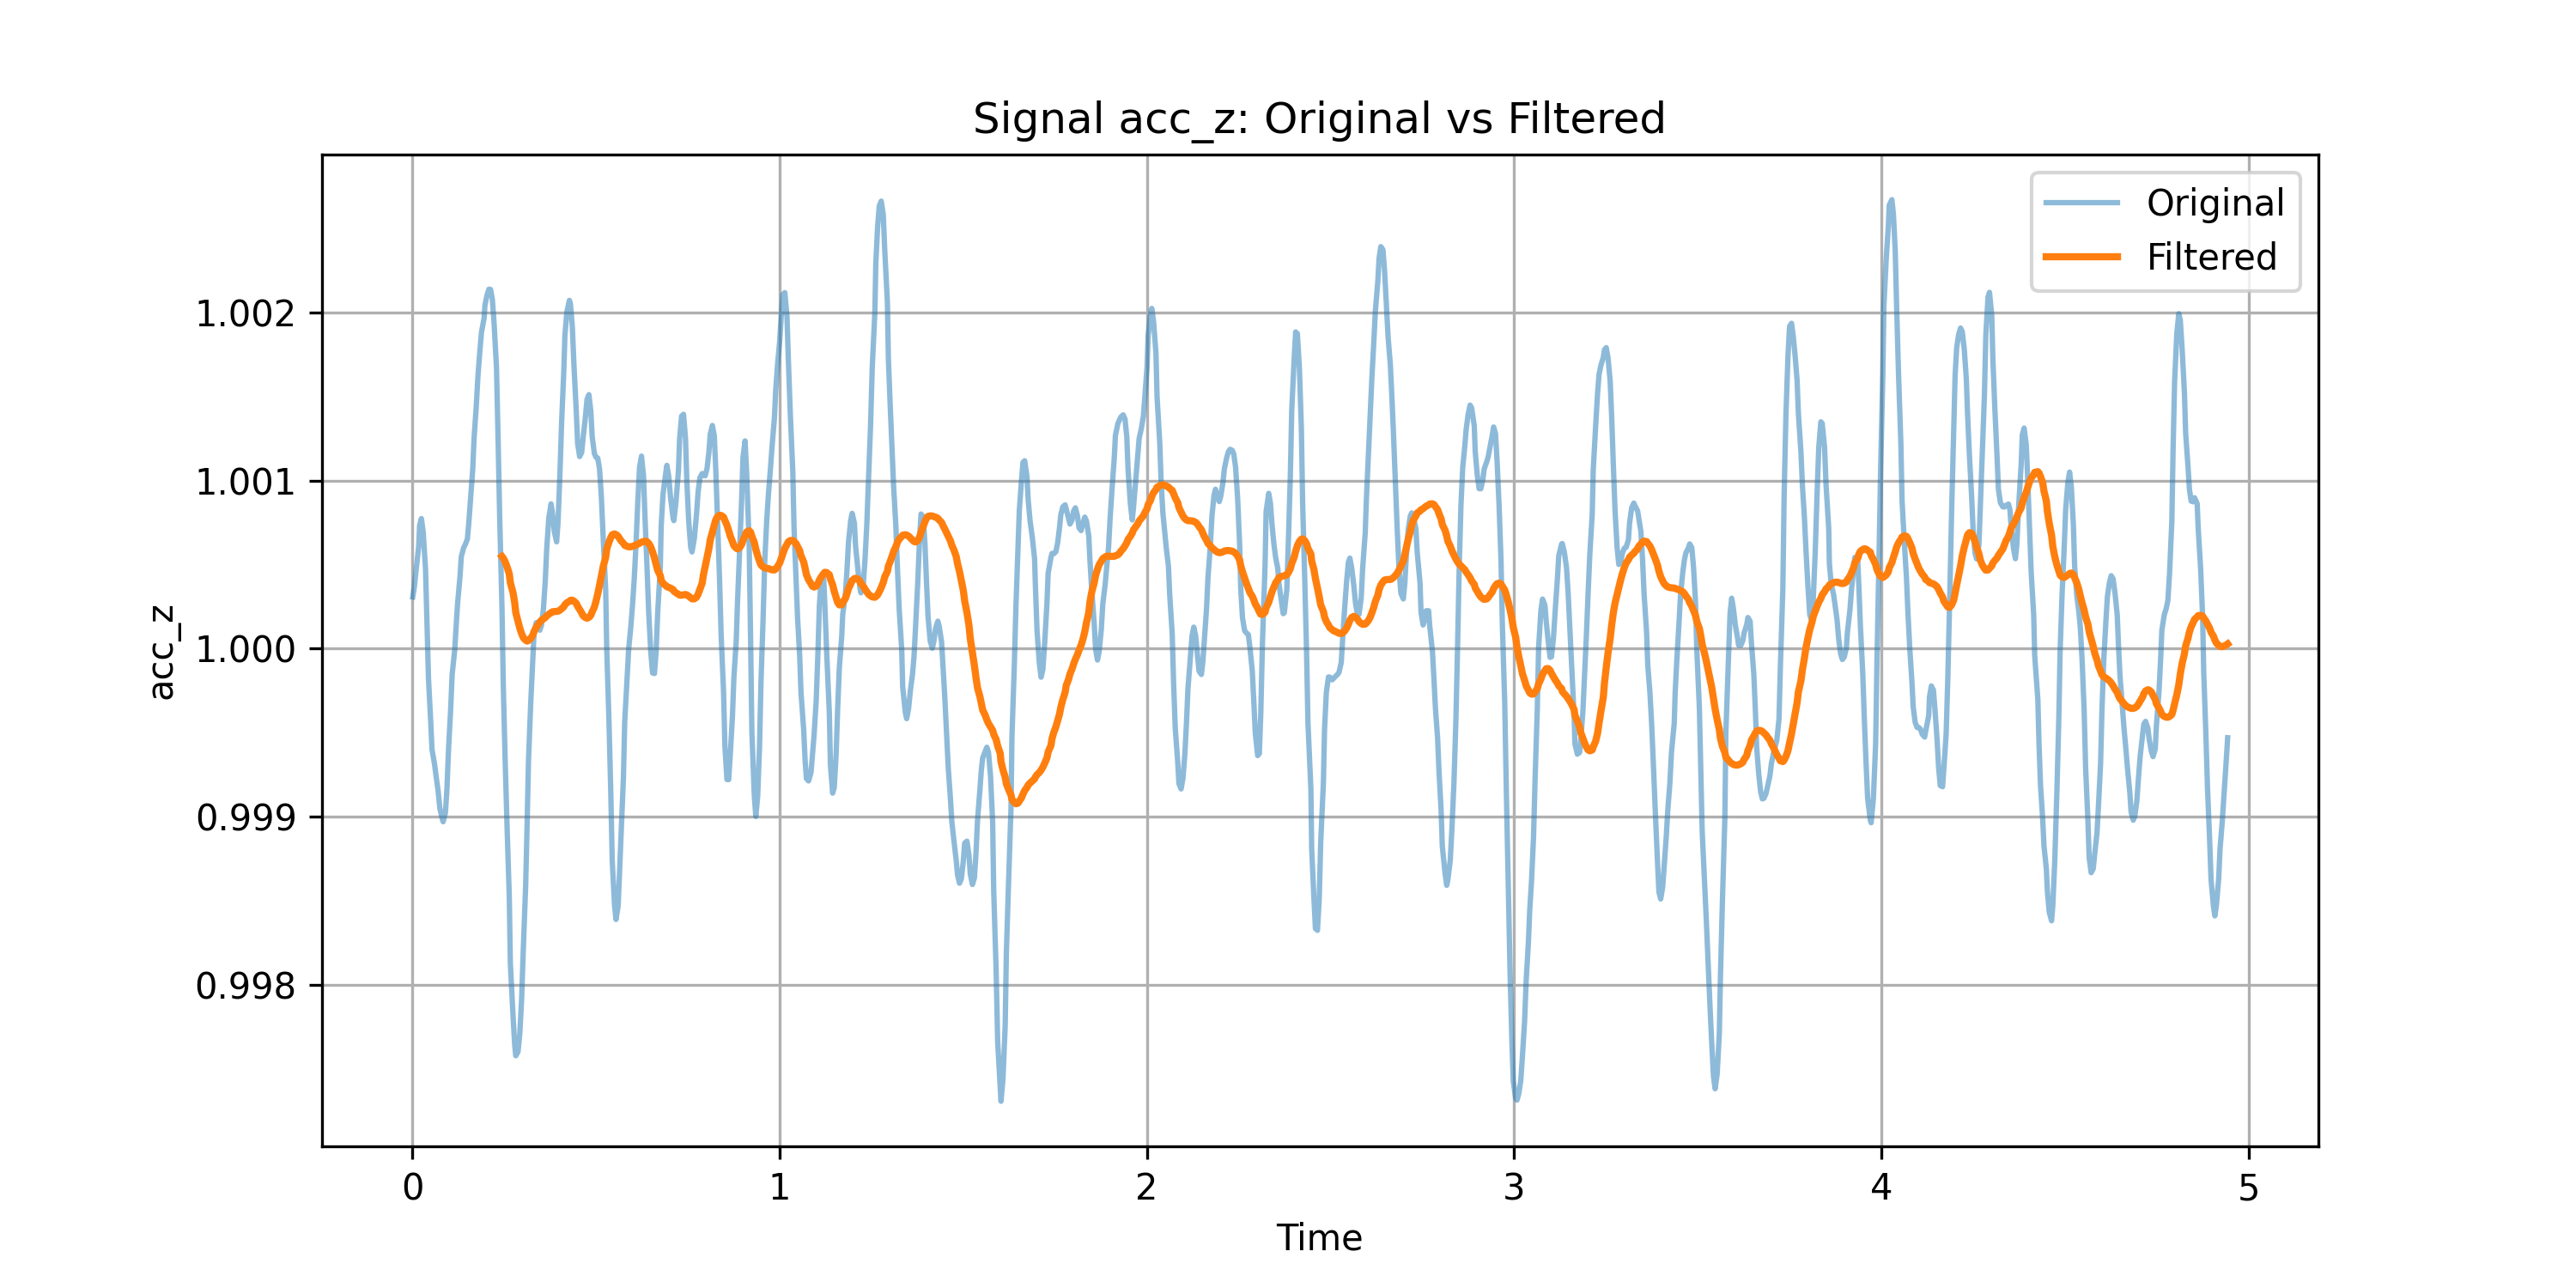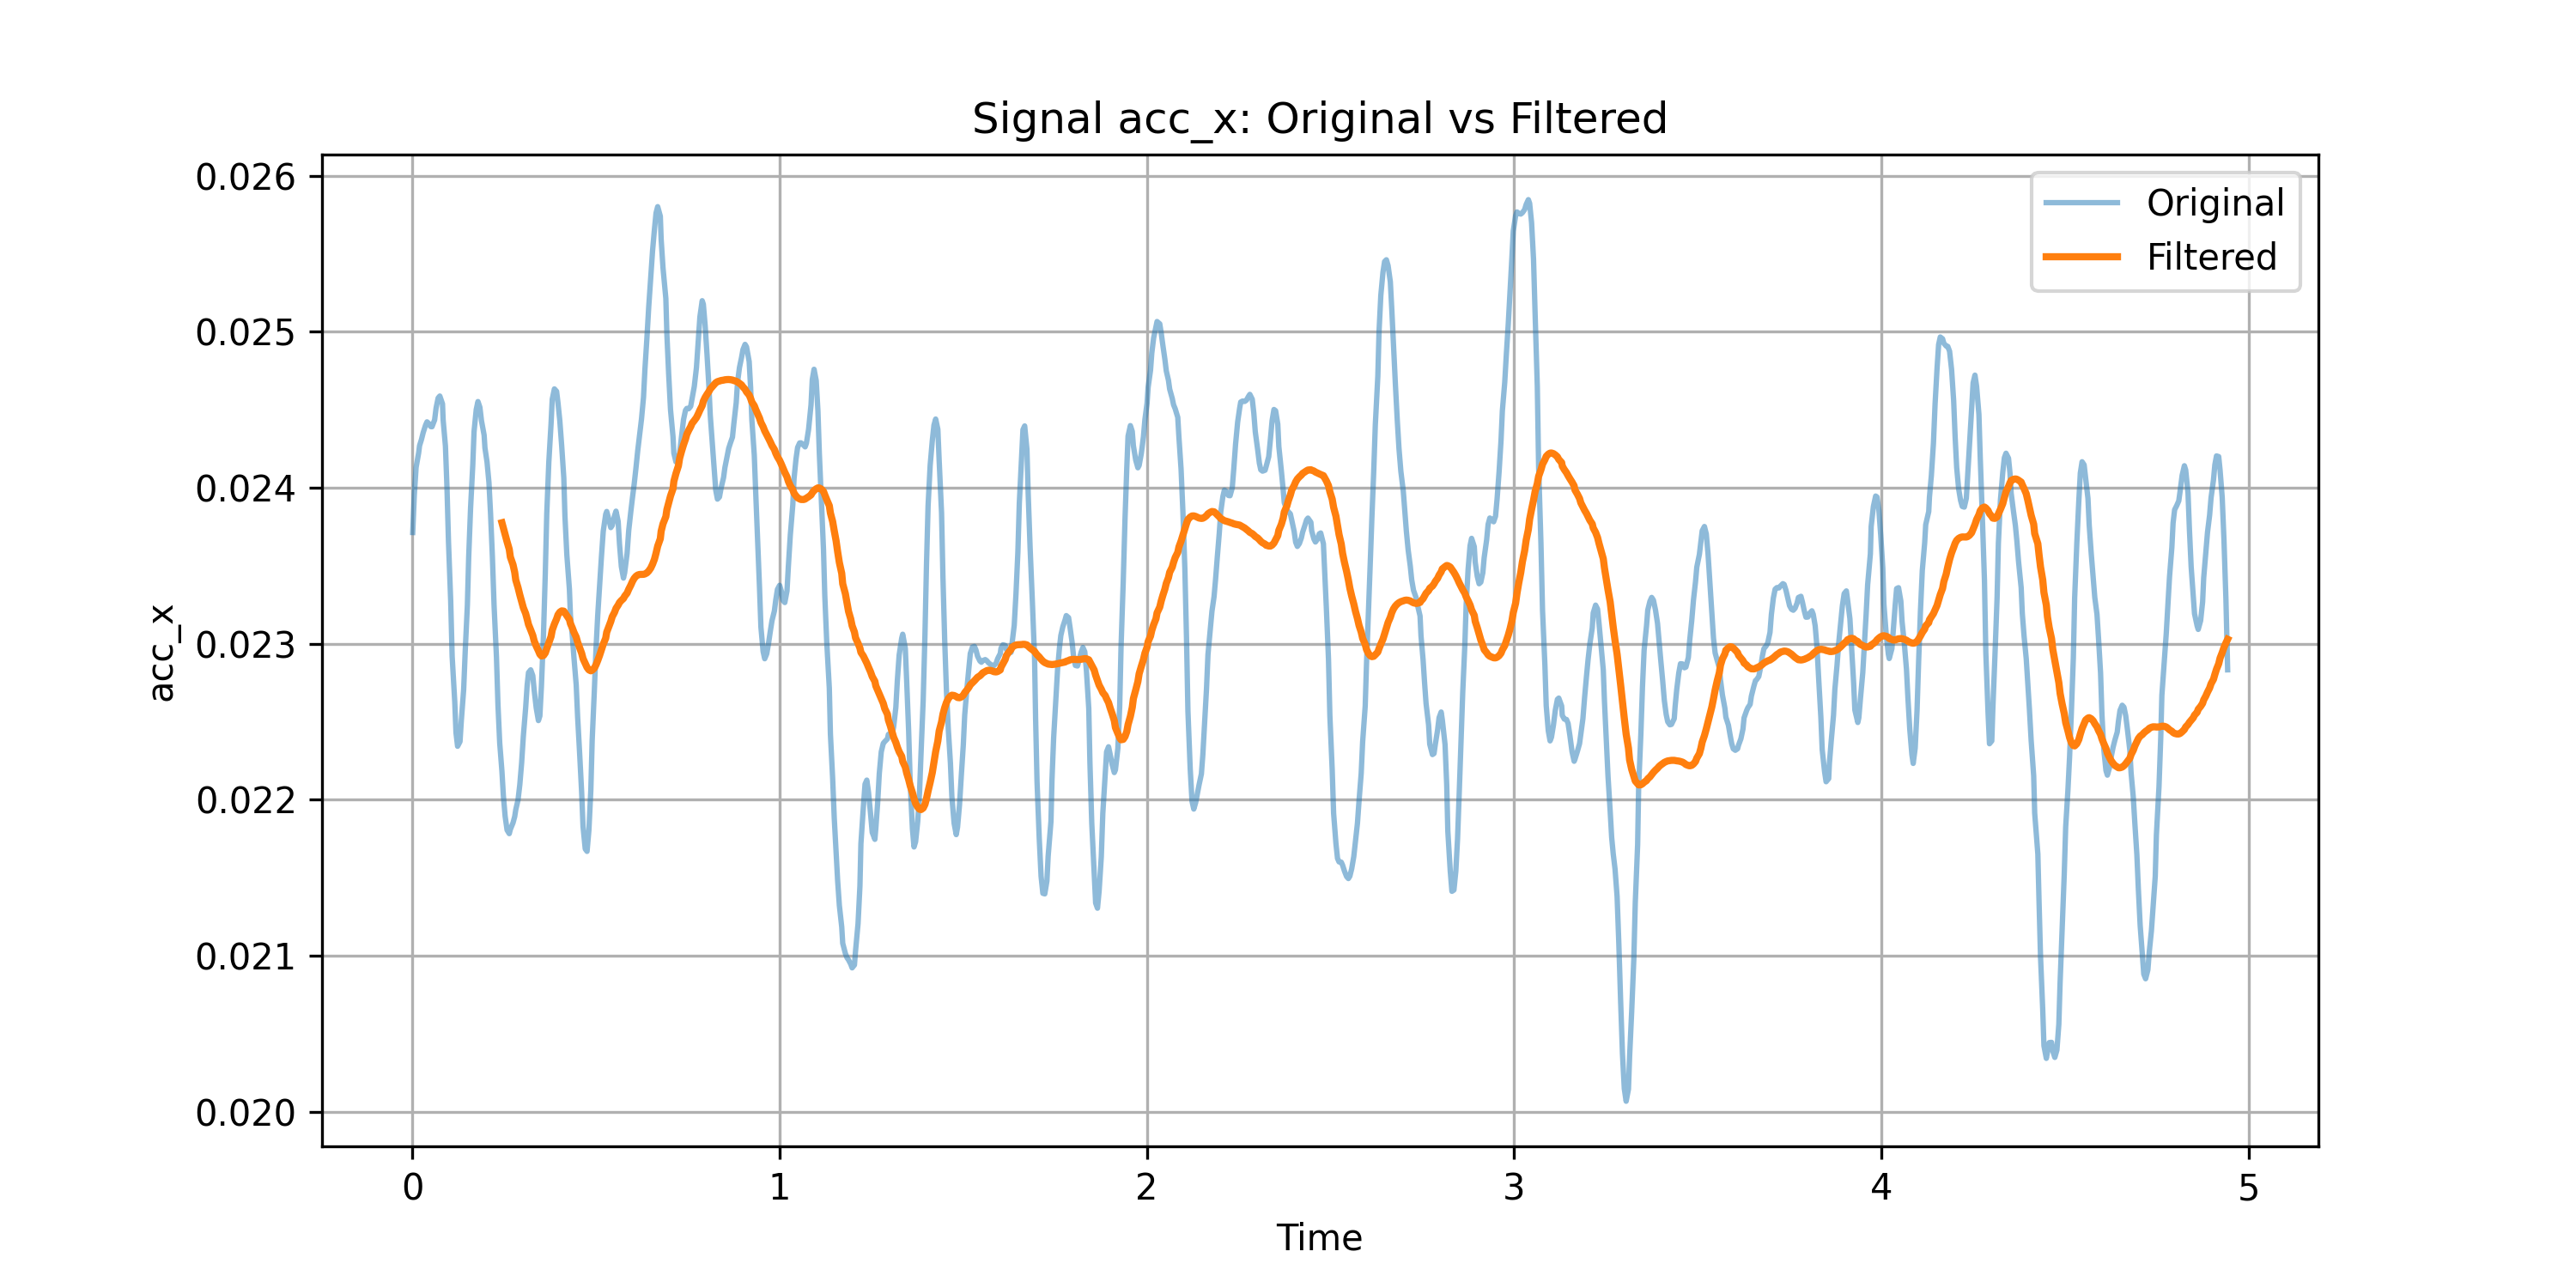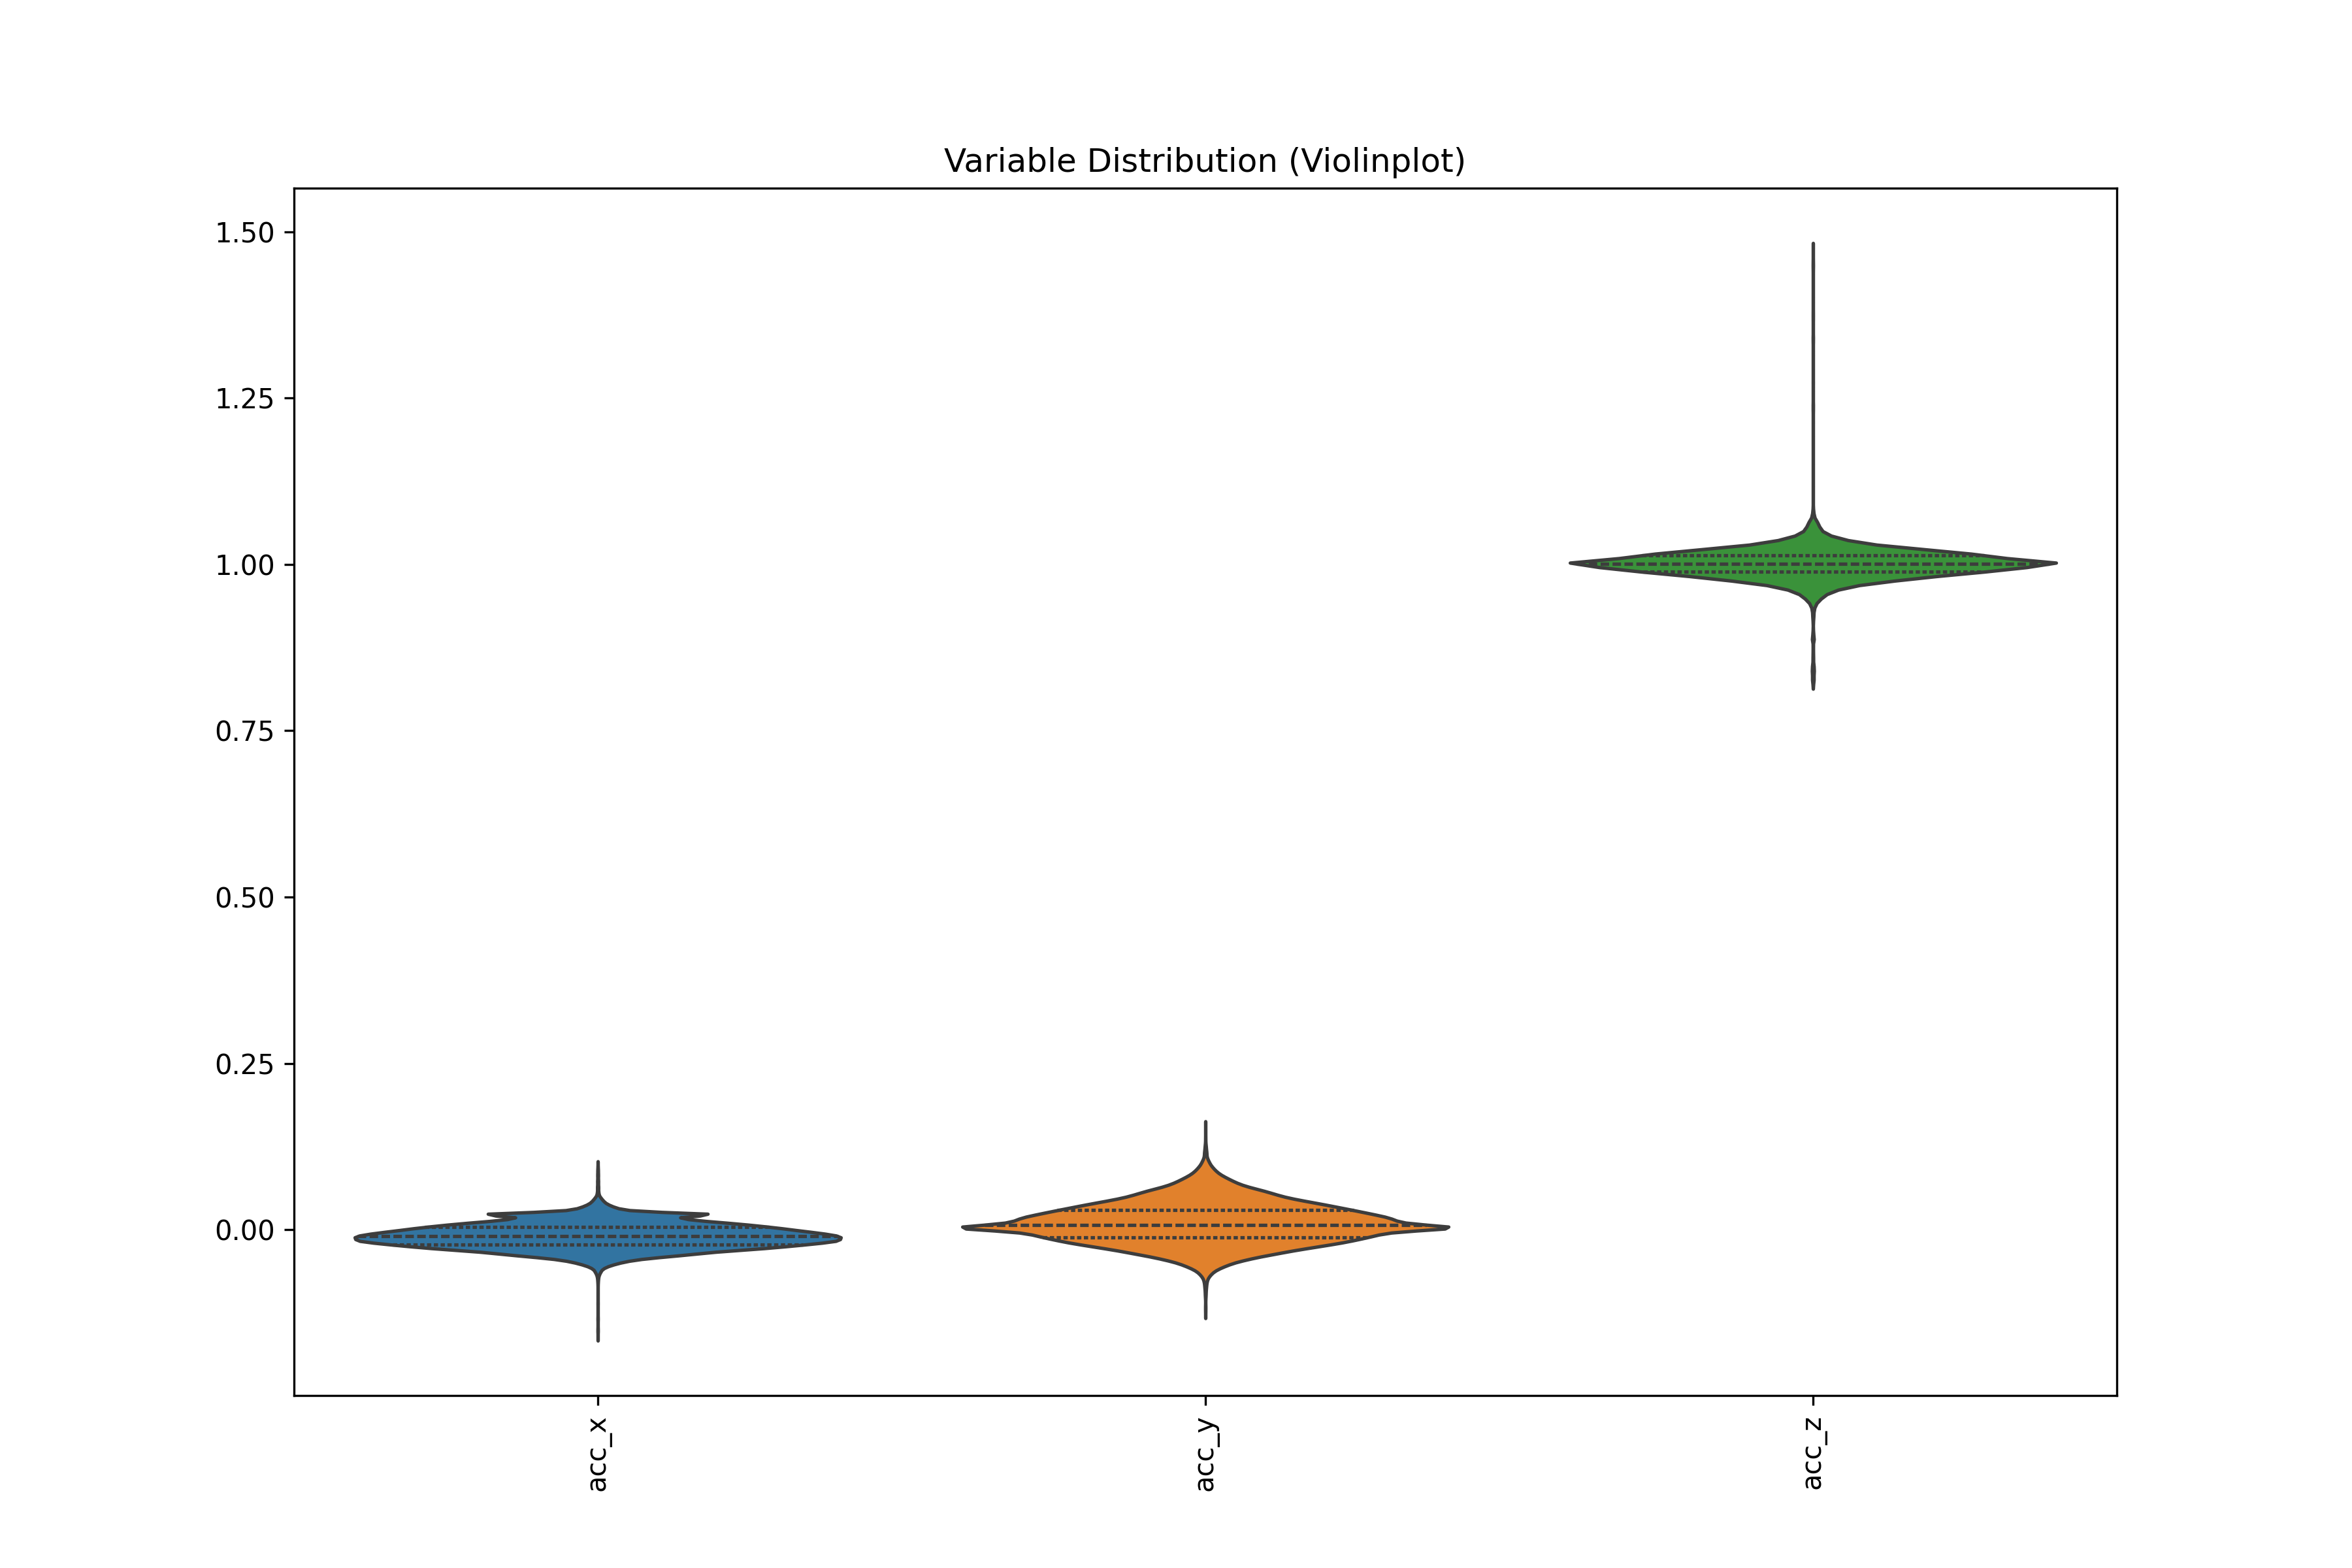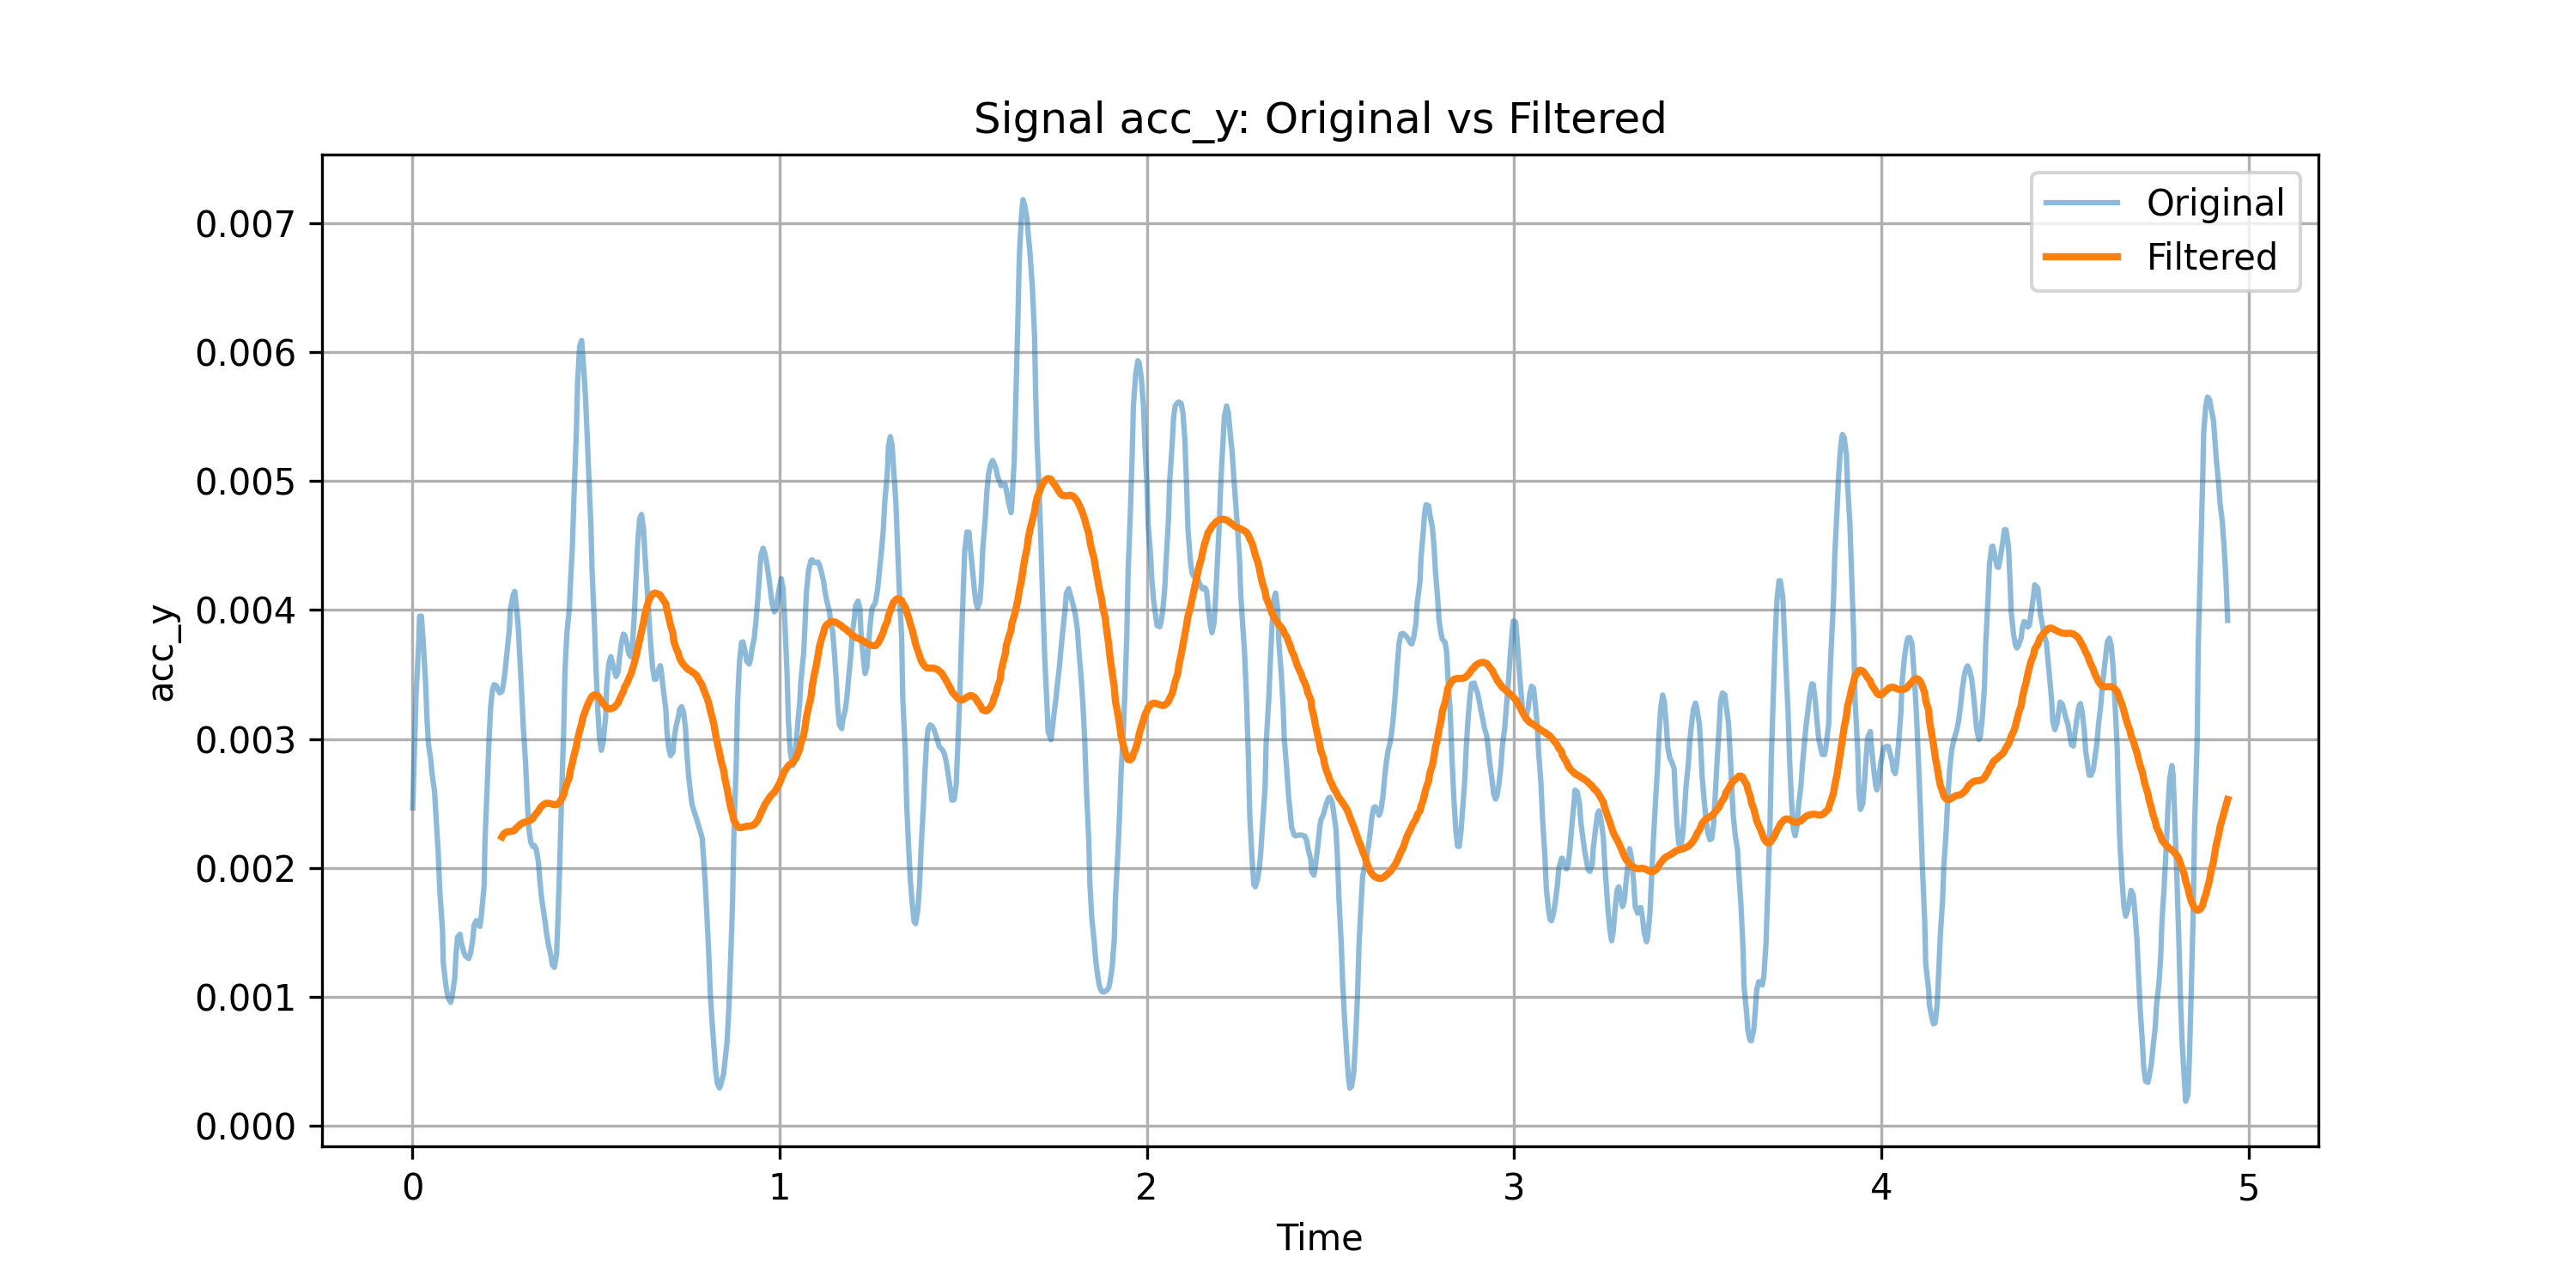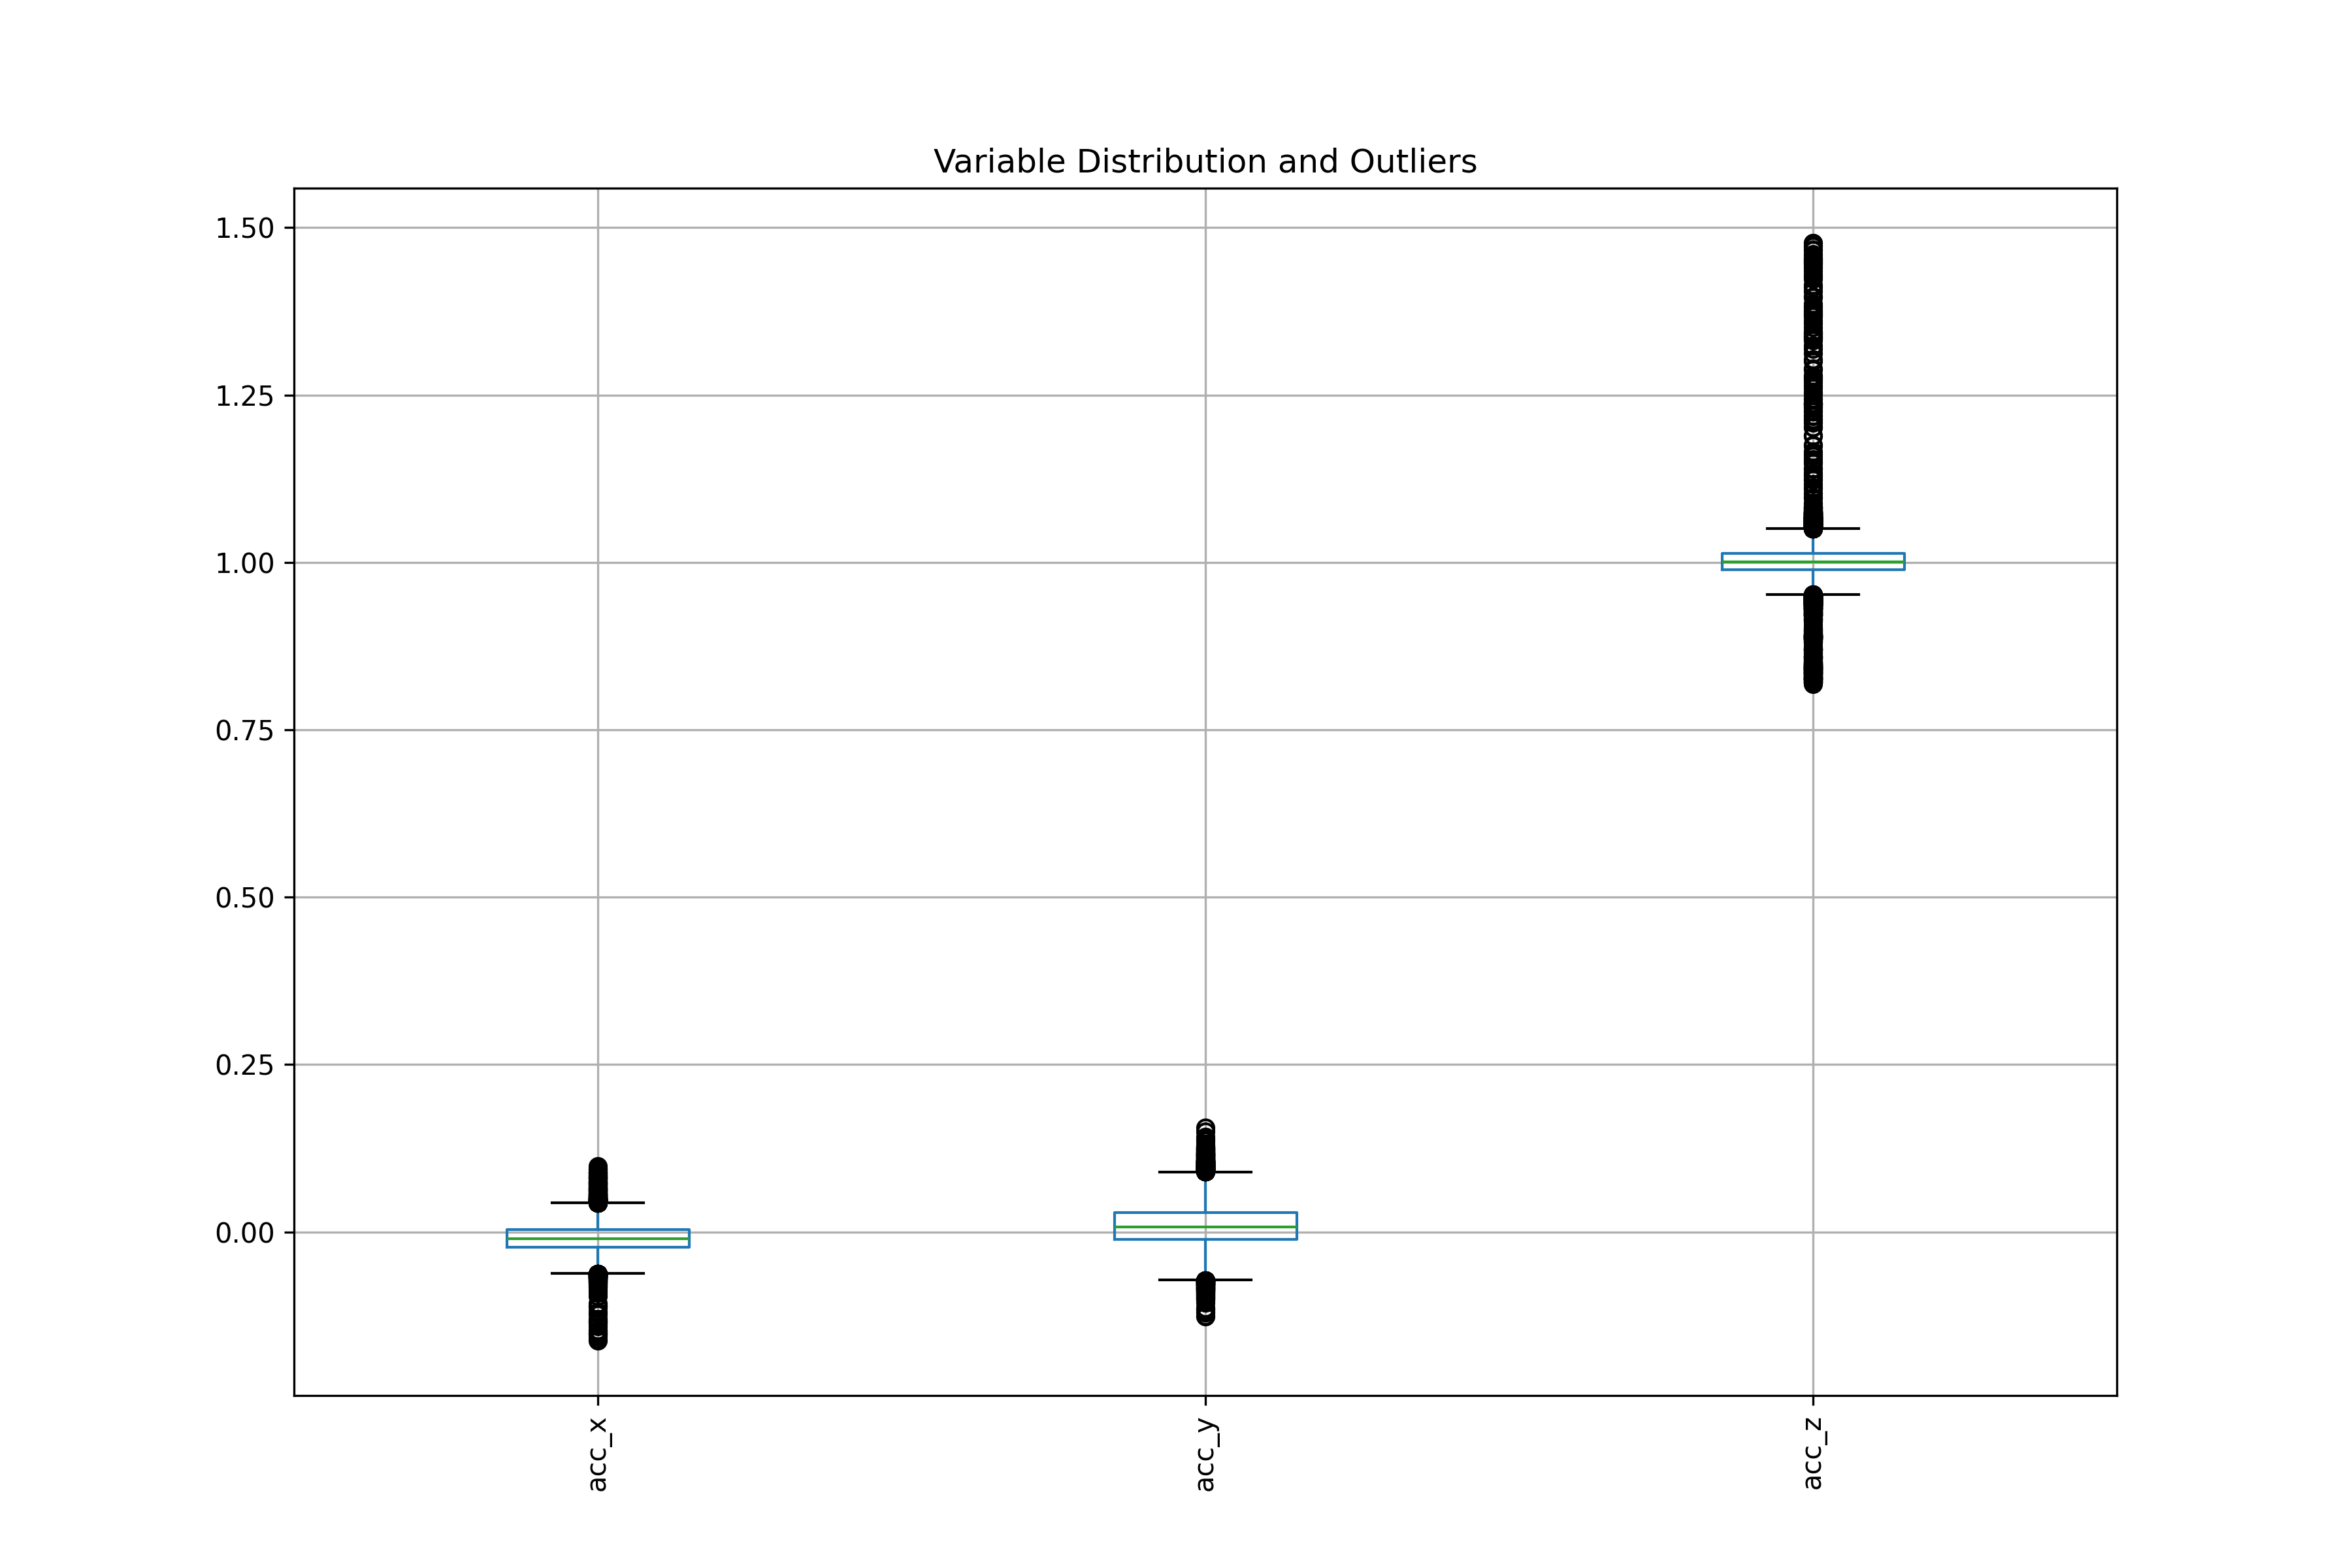

#  Visualization: correlation heatmap

The visualization module contains small helper functions for standard plots. The most relevant for analysis is the correlation heatmap, which helps to understand linear relationships between accelerometer axes.

In [ ]:
def generate_correlation_heatmap(df: pd.DataFrame,
                                 columns: list,
                                 figure_path: str) -> None:
    """
    Generate and save a correlation heatmap.

    Complexity: computing the correlation matrix is O(N * K^2),
    where N is number of rows and K is number of selected columns.
    Plotting is O(K^2) for the matrix cells.
    """
    corr = df[columns].corr()     # O(N * K^2)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr, annot=True, cmap="coolwarm")   # O(K^2)
    plt.title("Correlation Heatmap")

    os.makedirs(os.path.dirname(figure_path), exist_ok=True)  # O(1)
    plt.savefig(figure_path, dpi=300)                         # O(K^2)
    plt.close()


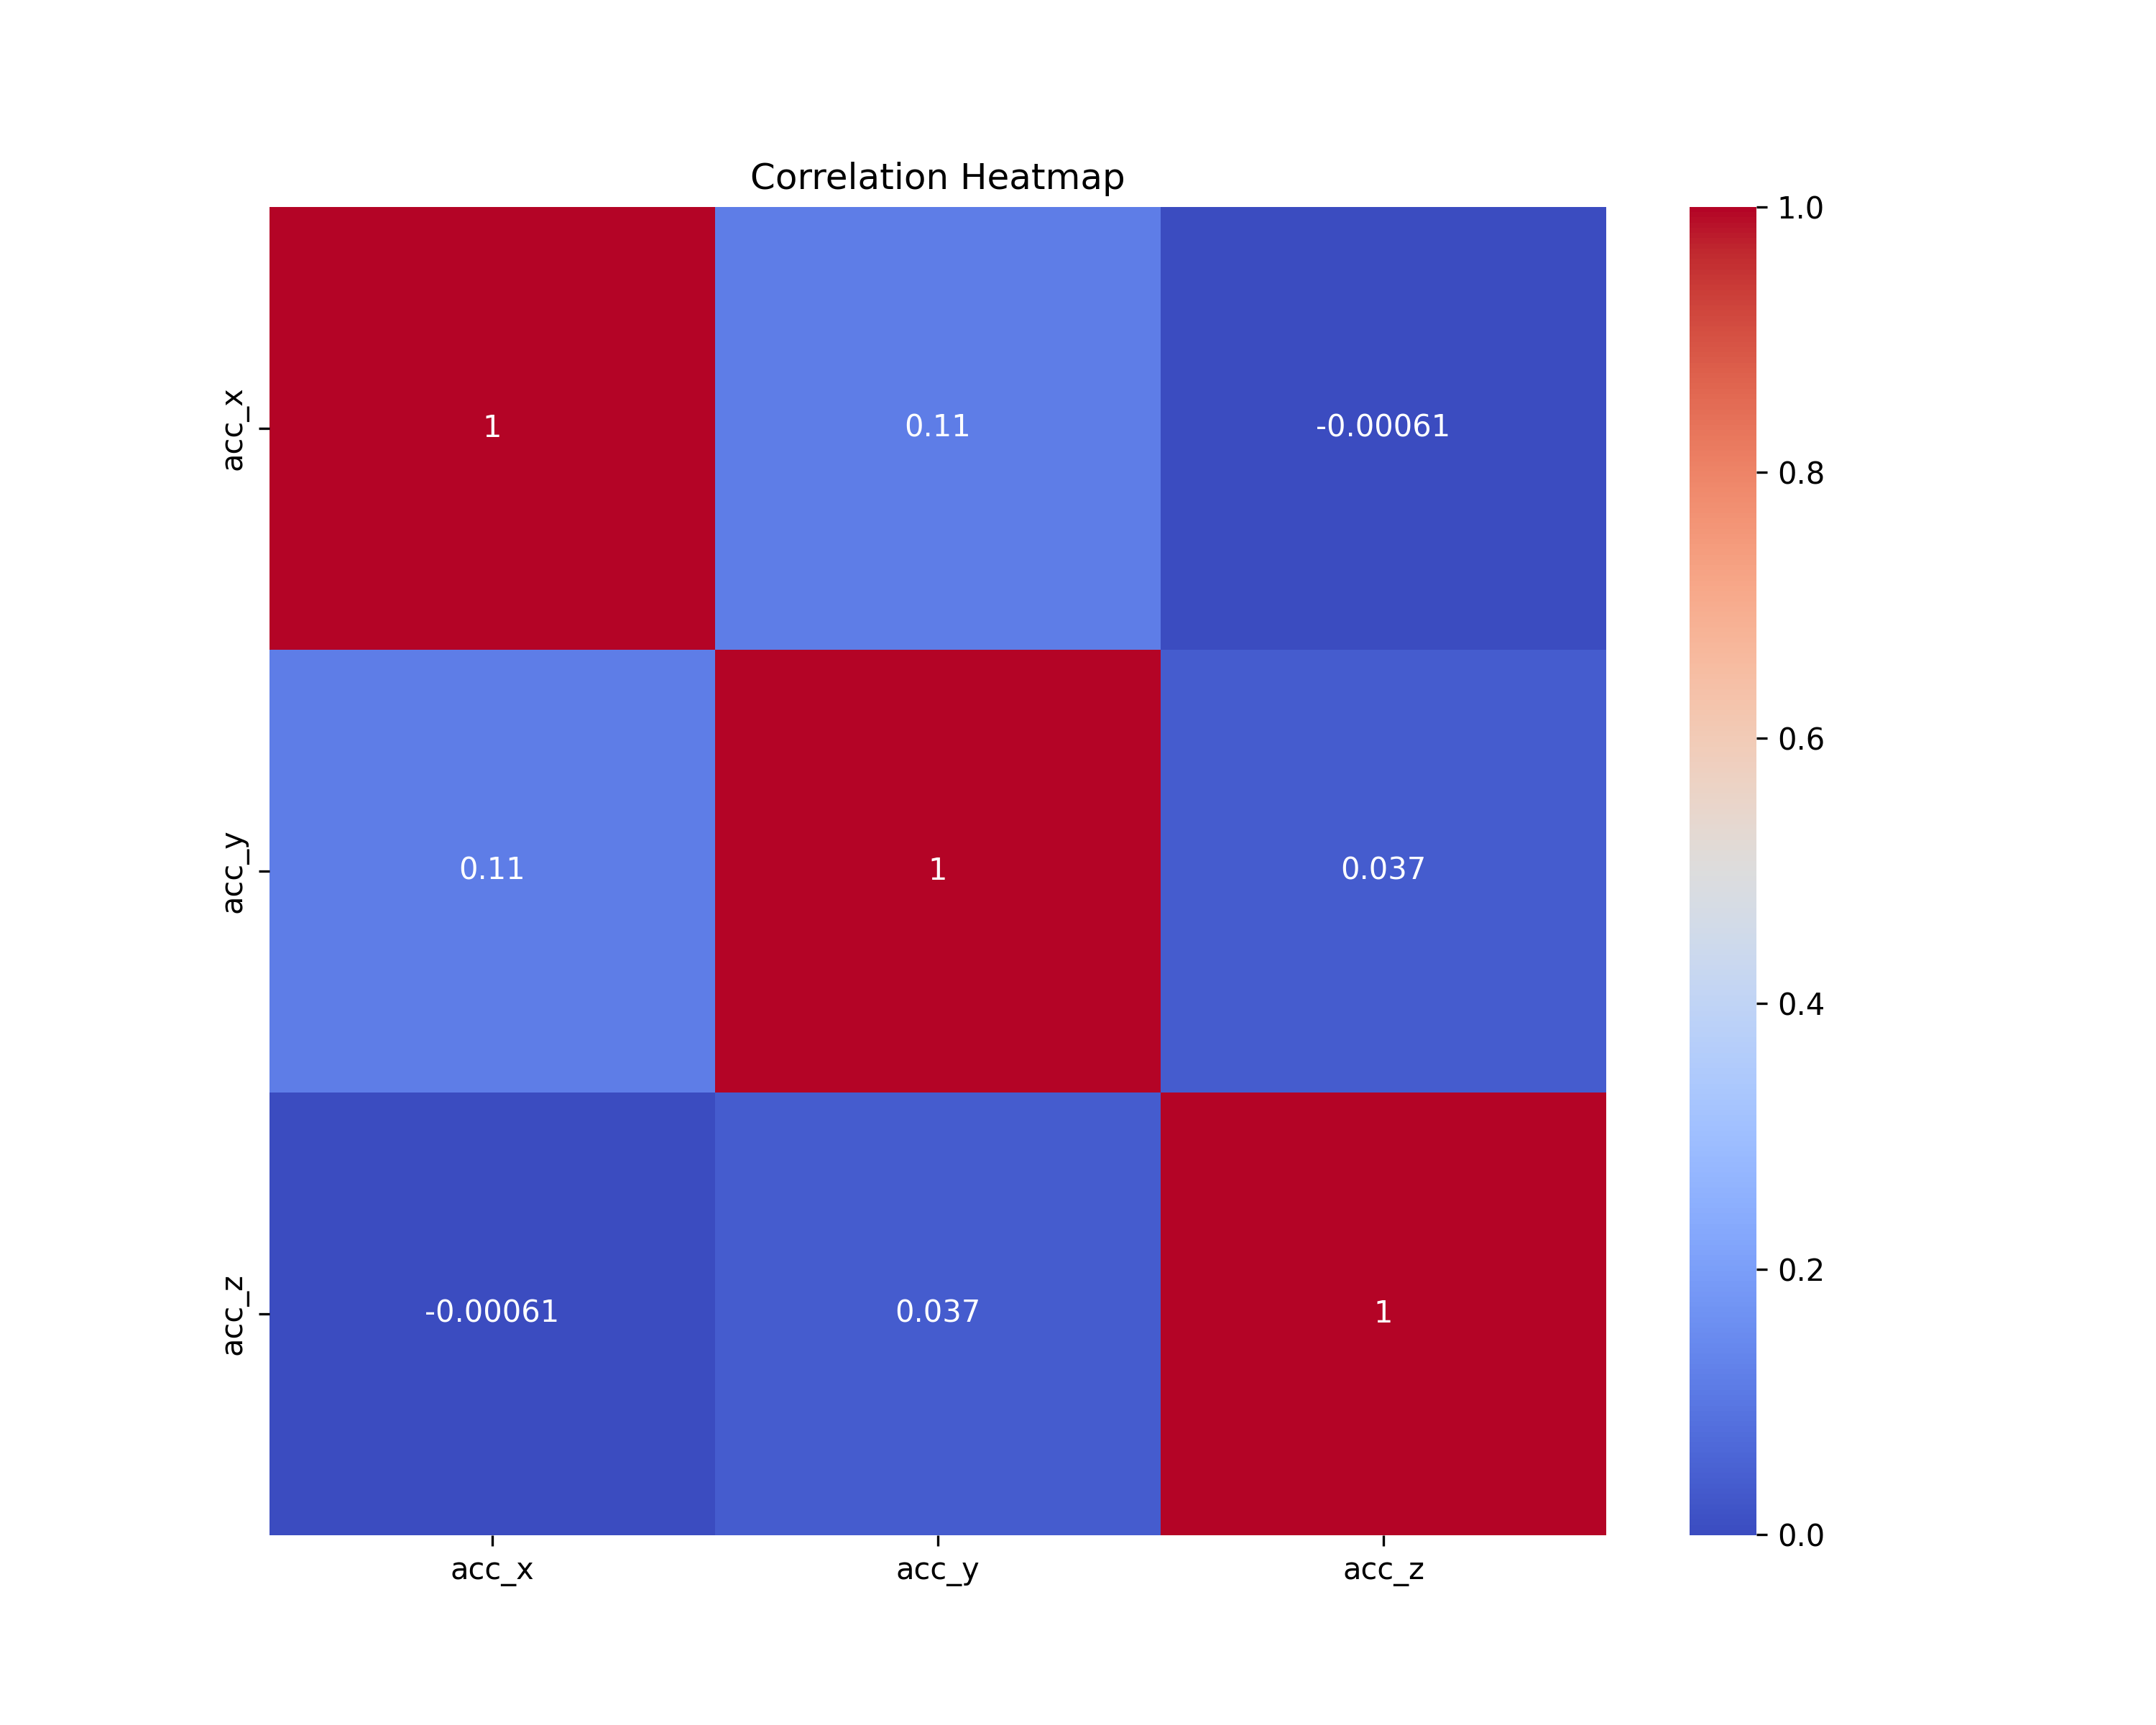

# Analysis: integration and segment summaries

The analysis module starts by integrating acceleration to velocity and by quantifying how many measurements are available per sensor group in the raw and processed datasets. This section documents those algorithms and their complexity.

In [ ]:
# =========  ACC → VEL INTEGRATION =========

class IntegratedSignal:
    """
    Trapezoidal integration from acceleration to velocity.

    Complexity: evaluating on N samples is O(N).
    """
    def __init__(self, time: np.ndarray, values: np.ndarray, name: str = ""):
        self.time = np.asarray(time)     # O(N)
        self.values = np.asarray(values) # O(N)
        self.name = name                 # O(1)

    def evaluate(self):
        """
        Apply trapezoidal integration.

        Complexity: O(N).
        """
        mask = np.isfinite(self.time) & np.isfinite(self.values)   # O(N)
        t = self.time[mask]                                       # O(N)
        a = self.values[mask]                                     # O(N)

        v = np.zeros_like(a)                                      # O(N)
        if len(t) > 1:
            v[1:] = np.cumsum((a[:-1] + a[1:]) / 2 * np.diff(t))  # O(N)

        return t, a, v


def generate_integration_figure(df: pd.DataFrame,
                                time_column: str,
                                acc_columns: list,
                                max_samples: int,
                                figure_path: str) -> None:
    """
    Generate a multi‑panel figure comparing acceleration and integrated velocity.

    Complexity: O(N * K), where N is number of samples and K is number of axes.
    """
    os.makedirs(os.path.dirname(figure_path), exist_ok=True)       # O(1)

    cols_ok = [c for c in acc_columns if c in df.columns]          # O(K)
    if len(cols_ok) == 0:
        return

    n = len(cols_ok)
    fig, axes = plt.subplots(n, 1, figsize=(12, 3.5 * n), sharex=True)
    if n == 1:
        axes = [axes]

    time = df[time_column].values                                  # O(N)

    for i, col in enumerate(cols_ok):                              # Loop over K axes
        acc = df[col].values                                       # O(N)
        integ = IntegratedSignal(time, acc, col)
        t, a, v = integ.evaluate()                                 # O(N)

        limit = min(len(t), max_samples)
        axes[i].plot(t[:limit], a[:limit], label=f"{col} (acc)", alpha=0.6)  # O(limit)
        axes[i].plot(t[:limit], v[:limit], label=f"{col} (vel)", linewidth=2) # O(limit)
        axes[i].set_ylabel(col)
        axes[i].legend()
        axes[i].grid()

    axes[-1].set_xlabel(time_column)
    plt.suptitle("Integration: Acceleration → Velocity", fontsize=14)
    plt.tight_layout()
    plt.savefig(figure_path, dpi=300)                              # O(N * K)
    plt.close()


# ========= 2. SEGMENT SUMMARY TABLES =========

def segment_summary(df: pd.DataFrame, segments: dict) -> pd.DataFrame:
    """
    Compute total, missing and percentage of missing values for each sensor group.

    Complexity: O(N * S), where S is the total number of columns across all segments.
    """
    rows = []
    for name, cols in segments.items():        # Loop over segment groups
        existing_cols = [c for c in cols if c in df.columns]       # O(S)

        if len(existing_cols) == 0:
            rows.append([name, 0, 0, np.nan])
            continue

        total = int(np.prod(df[existing_cols].shape))              # O(1)
        missing = int(df[existing_cols].isnull().sum().sum())     # O(N * |existing_cols|)
        pct = missing / total * 100 if total > 0 else np.nan      # O(1)

        rows.append([name, total, missing, round(pct, 2)])

    return pd.DataFrame(rows, columns=["Segment", "Total", "Missing", "%Missing"])


def save_segment_summary_png(df: pd.DataFrame,
                             segments: dict,
                             table_path: str) -> None:
    """
    Render the segment summary as a PNG table.

    Complexity: dominated by segment_summary (O(N * S))
    and by drawing the table O(G), where G is number of groups.
    """
    summary = segment_summary(df, segments)        # O(N * S)
    df_to_png(summary, table_path, title="Segment Summary")  # O(G)


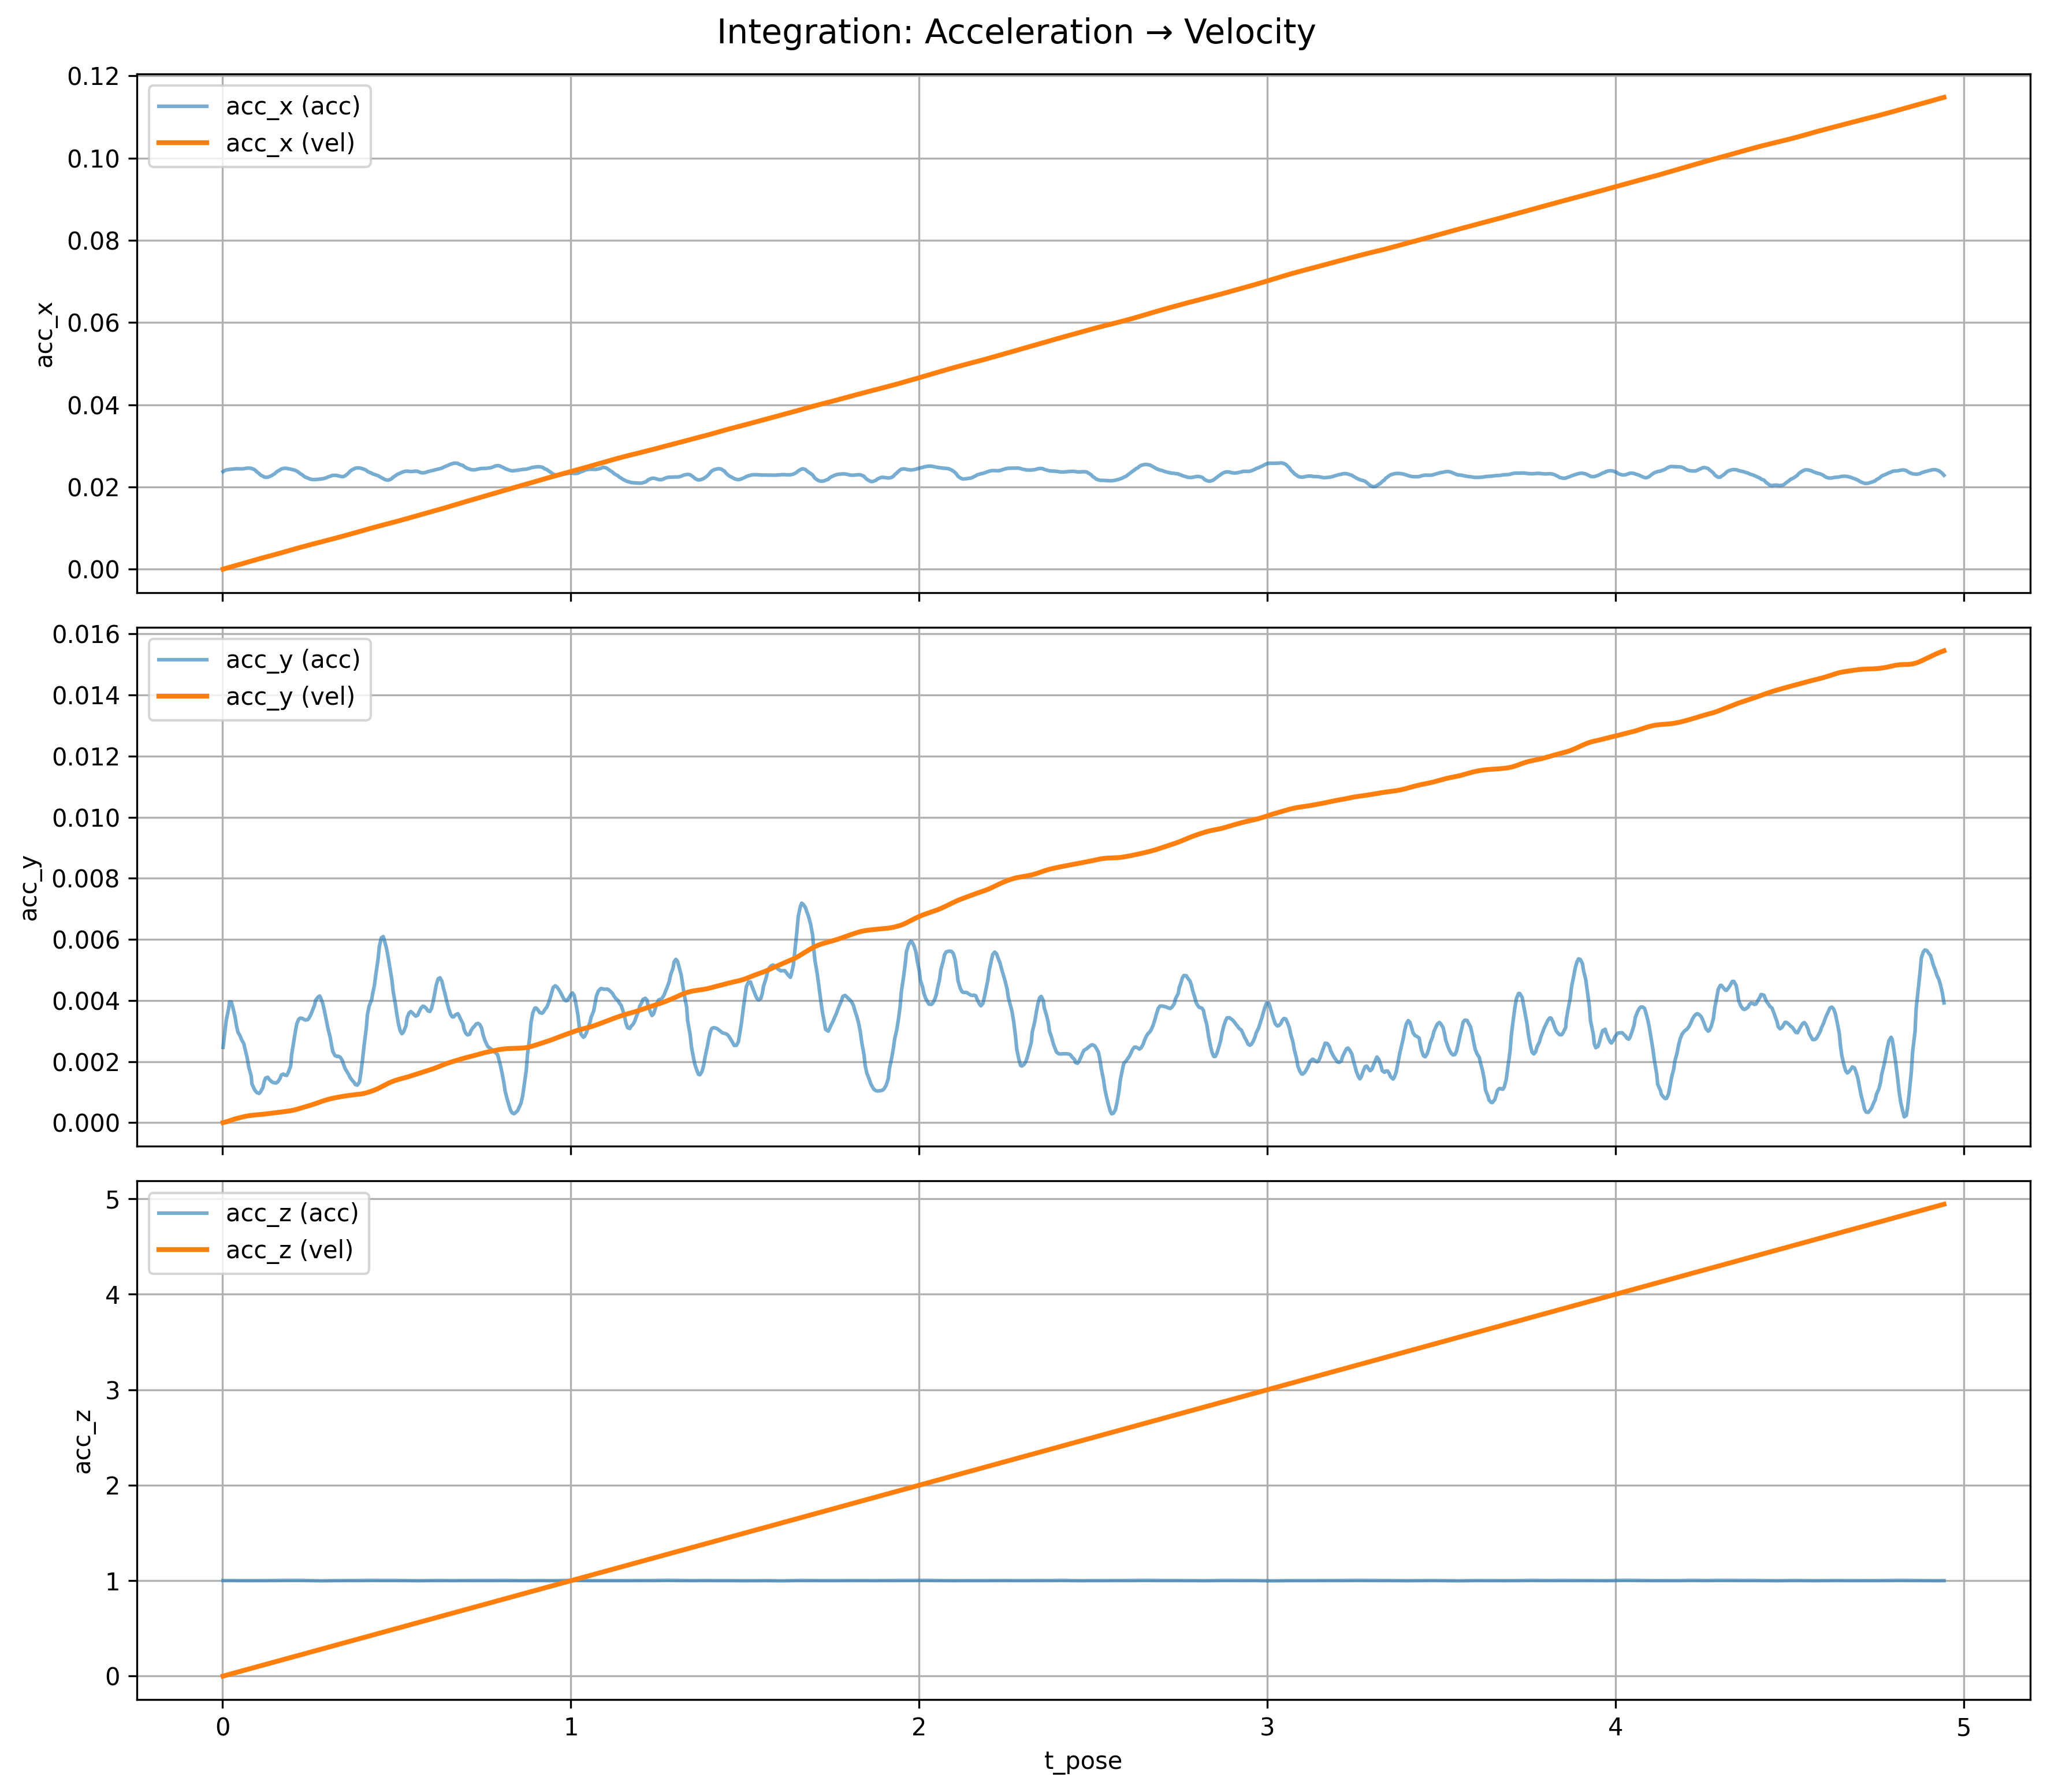

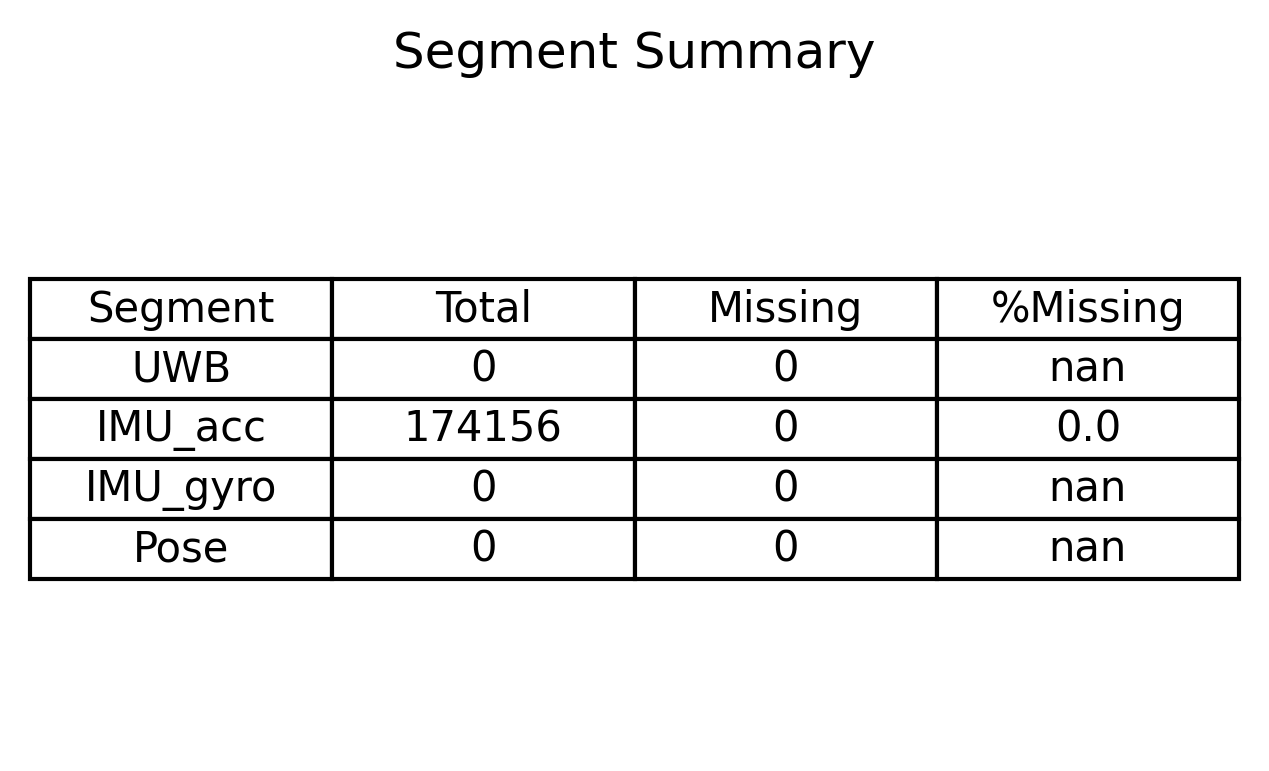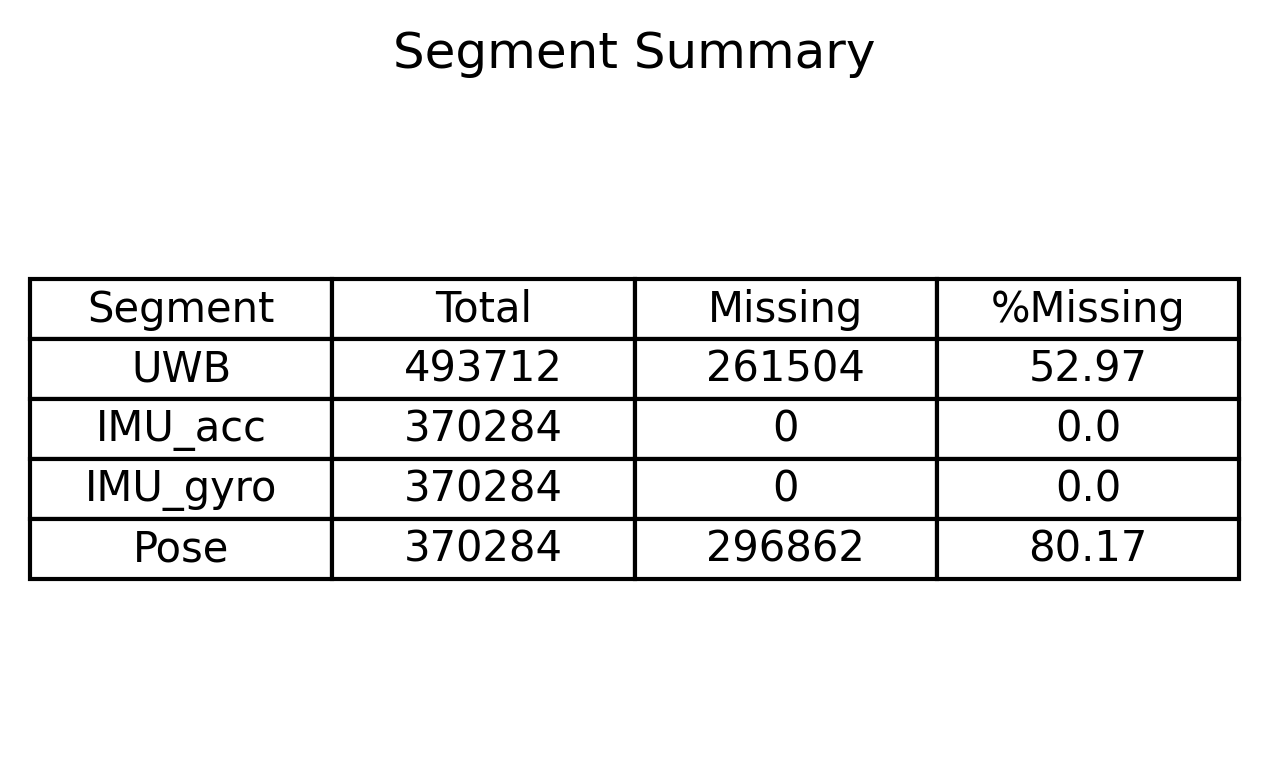

# Analysis: motion classes, features and Random Forest

The final part of the analysis defines global motion classes using the accelerometer magnitude, extracts time‑ and frequency‑domain features from each axis, and trains a Random Forest classifier. Below we show the core functions with their complexity and then include the pre‑computed tables and figures.

In [ ]:
# =========  GLOBAL MOTION CLASSES =========

def define_global_motion_classes(df: pd.DataFrame,
                                 imu_acc_columns: list,
                                 p_low: float = 0.33,
                                 p_high: float = 0.66) -> pd.DataFrame:
    """
    Define 'final_global_mobile_state' using the acceleration magnitude
    and two global percentiles.

    Complexity: O(N * K), where K is number of accelerometer axes.
    """
    df_mod = df.copy()                                         # O(N * K)

    cols = [c for c in imu_acc_columns if c in df_mod.columns] # O(K)
    if len(cols) == 0:
        df_mod["final_global_mobile_state"] = np.nan           # O(N)
        return df_mod

    acc_sq = np.zeros(len(df_mod))                             # O(N)
    for c in cols:                                             # Loop over K axes
        acc_sq += df_mod[c].fillna(0).values ** 2              # O(N) each → O(N * K)
    df_mod["acc_mod"] = np.sqrt(acc_sq)                        # O(N)

    low_thr = df_mod["acc_mod"].quantile(p_low)                # O(N)
    high_thr = df_mod["acc_mod"].quantile(p_high)              # O(N)

    def label_from_acc_mod(x):
        if x < low_thr:
            return "repose"
        elif x > high_thr:
            return "motion"
        else:
            return "transition"

    df_mod["final_global_mobile_state"] = df_mod["acc_mod"].apply(label_from_acc_mod)  # O(N)

    return df_mod


def save_class_distribution_png(df: pd.DataFrame,
                                table_path: str) -> None:
    """
    Save the distribution of motion classes as a PNG table.

    Complexity: O(N) to compute value_counts, O(C) to render C classes.
    """
    if "final_global_mobile_state" not in df.columns:
        df_to_png(pd.DataFrame(), table_path, title="Empty classes")
        return

    vc = df["final_global_mobile_state"].value_counts().reset_index()   # O(N)
    vc.columns = ["Class", "Count"]

    df_to_png(vc, table_path, title="Class Distribution")               # O(C)


# ========= 4. ACC FEATURES =========

def extract_imu_acc_features(df: pd.DataFrame,
                             cols: list,
                             dt: float = 0.01) -> pd.DataFrame:
    """
    Extract time‑ and frequency‑domain features for each accelerometer axis:
    mean, standard deviation, RMS, mean frequency and peak frequency.

    Complexity: O(N * K log N), dominated by the FFT per axis.
    """
    rows = []
    for col in cols:                             # Loop over K axes
        if col not in df.columns:
            rows.append([col, np.nan, np.nan, np.nan, np.nan, np.nan])
            continue

        arr = df[col].dropna().values           # O(N)
        if len(arr) == 0:
            rows.append([col, np.nan, np.nan, np.nan, np.nan, np.nan])
            continue

        mean = float(np.mean(arr))              # O(N)
        std = float(np.std(arr))                # O(N)
        rms = float(np.sqrt(np.mean(arr ** 2))) # O(N)

        N = len(arr)
        yf = fft(arr)                           # O(N log N)
        xf = np.linspace(0.0, 1.0 / (2 * dt), N // 2)   # O(N)
        mag = 2.0 / N * np.abs(yf[:N // 2])              # O(N)

        if np.sum(mag) > 0:                     # O(N)
            mean_freq = float(np.sum(xf * mag) / np.sum(mag))  # O(N)
        else:
            mean_freq = 0.0

        peak_freq = float(xf[np.argmax(mag)]) if len(mag) > 0 else 0.0  # O(N)

        rows.append([col, mean, std, rms, mean_freq, peak_freq])

    return pd.DataFrame(
        rows,
        columns=["variable", "mean", "std", "rms", "mean_freq", "peak_freq"]
    )


def save_features_png(df_feats: pd.DataFrame,
                      table_path: str) -> None:
    """
    Save the accelerometer feature table as PNG, formatting numbers
    to 4 decimal places for readability.

    Complexity: O(R * C) to format R rows and C numeric columns.
    """
    df_fmt = df_feats.copy()
    num_cols = ["mean", "std", "rms", "mean_freq", "peak_freq"]
    for c in num_cols:                           # Loop over C columns
        if c in df_fmt.columns:
            df_fmt[c] = df_fmt[c].map(
                lambda x: f"{x:.4f}" if pd.notnull(x) else ""
            )                                    # O(R)

    df_to_png(df_fmt, table_path, title="ACC Features", fontsize=9)   # O(R * C)


# ========= 5. RANDOM FOREST CLASSIFIER =========

def train_random_forest_acc(df: pd.DataFrame,
                            feature_cols: list,
                            label_col: str,
                            report_table_path: str,
                            cm_figure_path: str,
                            test_size: float = 0.2,
                            random_state: int = 42):
    """
    Train a Random Forest classifier on accelerometer channels
    and save both a classification report (table) and confusion matrix (figure).

    Complexity (rough): O(T * N log N), where T is number of trees and N number of samples.
    """
    df_valid = df.dropna(subset=feature_cols + [label_col])   # O(N * K)
    if len(df_valid) == 0:
        return pd.DataFrame(), np.array([]), []

    X = df_valid[feature_cols].values    # O(N * K)
    y = df_valid[label_col].values      # O(N)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, stratify=y, test_size=test_size, random_state=random_state
    )                                    # ≈ O(N)

    clf = RandomForestClassifier(n_estimators=100, random_state=random_state)
    clf.fit(X_train, y_train)            # ≈ O(T * N log N)

    y_pred = clf.predict(X_test)         # O(T * N_test)

    rep_dict = classification_report(
        y_test, y_pred, output_dict=True, zero_division=0
    )                                    # O(N_test)

    df_rep = pd.DataFrame(rep_dict).transpose().reset_index().rename(columns={"index": "label"})  # O(C)
    for c in df_rep.columns:             # Loop over columns
        if df_rep[c].dtype in [float, int]:
            df_rep[c] = df_rep[c].round(3)   # O(C * R)

    # Save classification report as table
    df_to_png(df_rep, report_table_path,
              title="Random Forest - Classification Report")   # O(C * R)

    # Confusion matrix
    labels = clf.classes_                                      # O(C)
    cm = confusion_matrix(y_test, y_pred, labels=labels)       # O(C^2)

    os.makedirs(os.path.dirname(cm_figure_path), exist_ok=True)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")                           # O(C^2)

    ax.set_xticks(range(len(labels)))
    ax.set_yticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=45)
    ax.set_yticklabels(labels)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title("Confusion Matrix - Random Forest")

    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.savefig(cm_figure_path, dpi=300)                       # O(C^2)
    plt.close()

    return df_rep, cm, labels


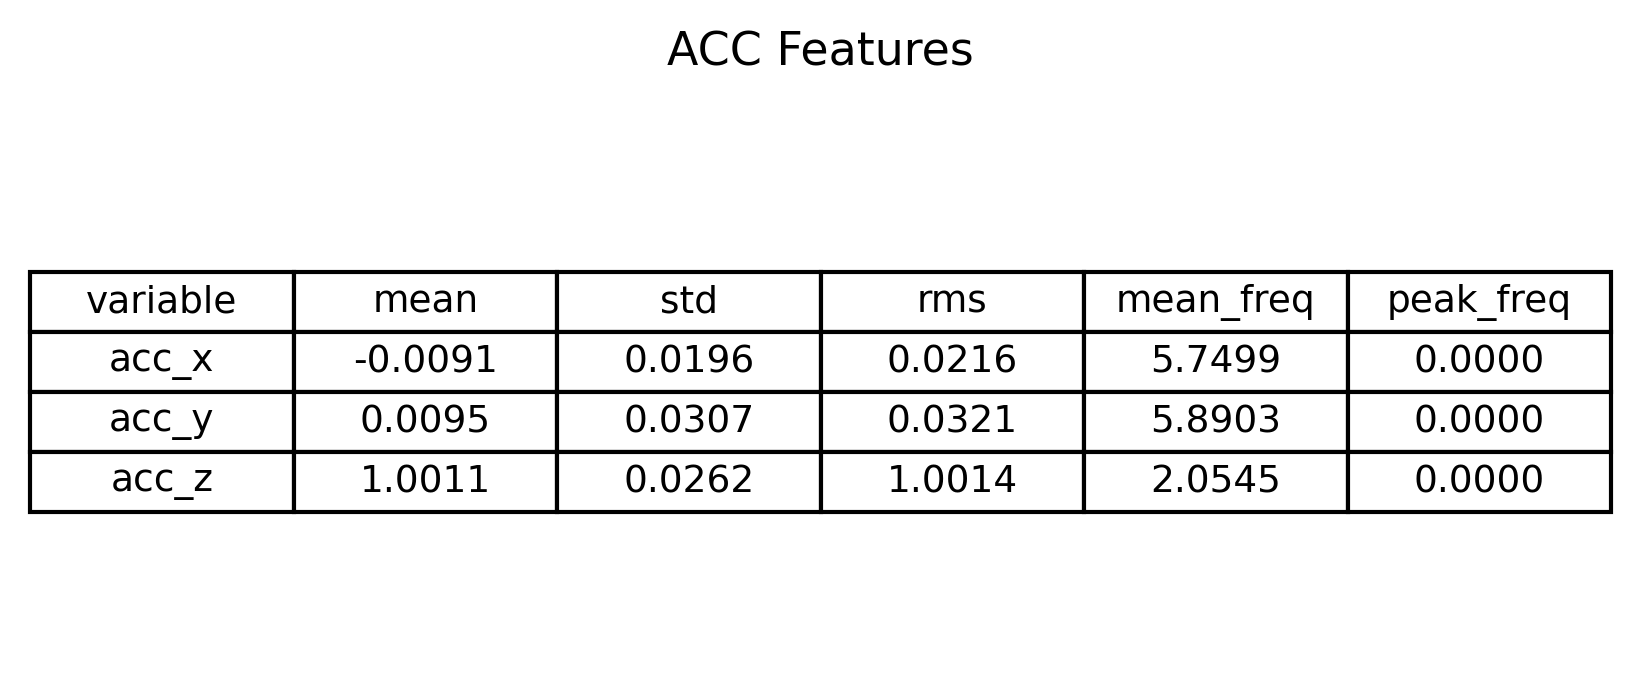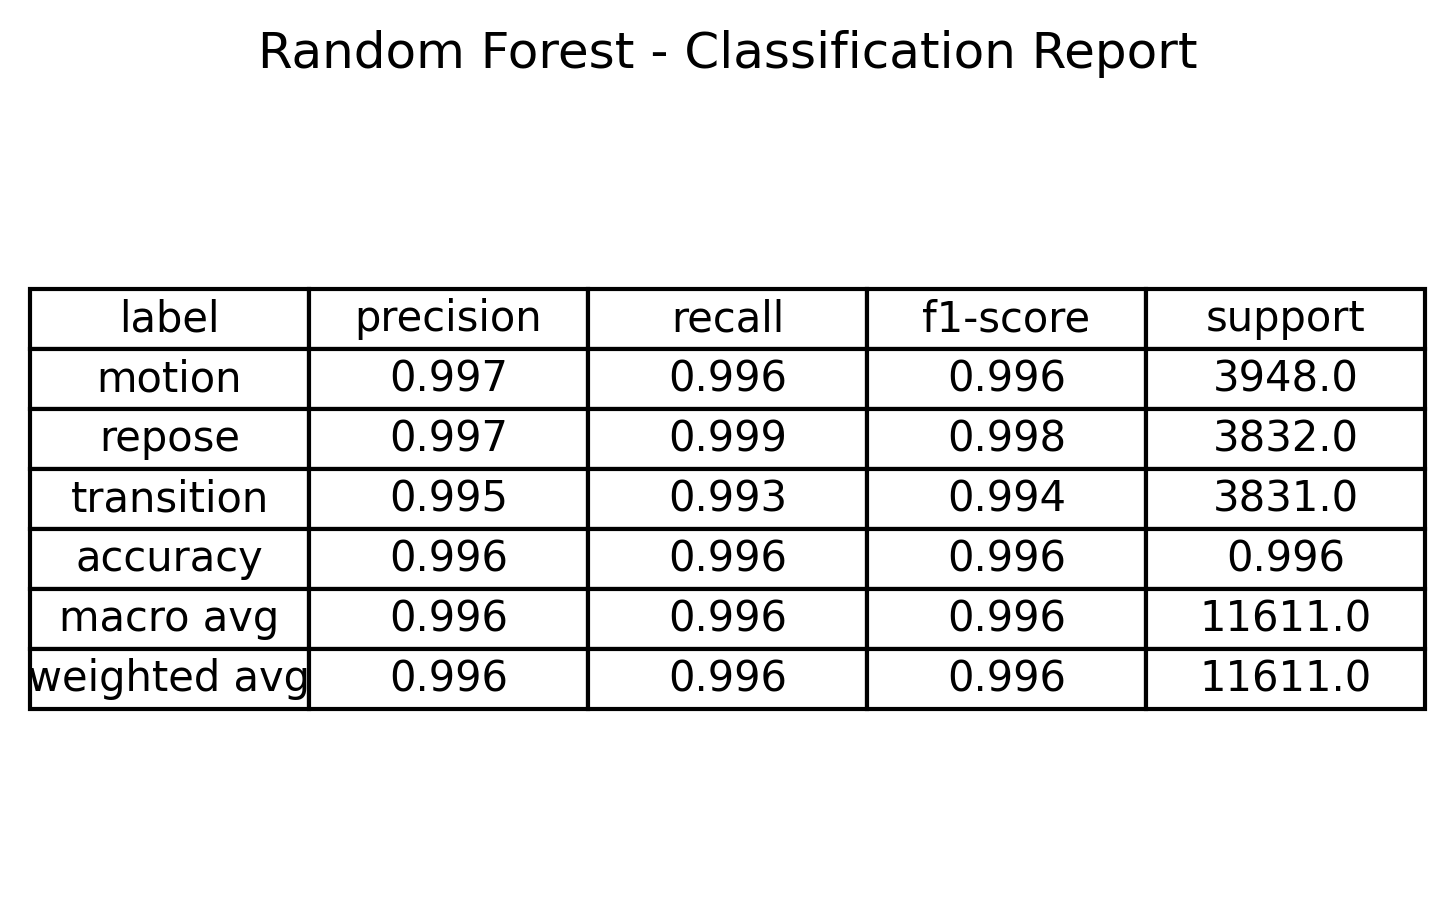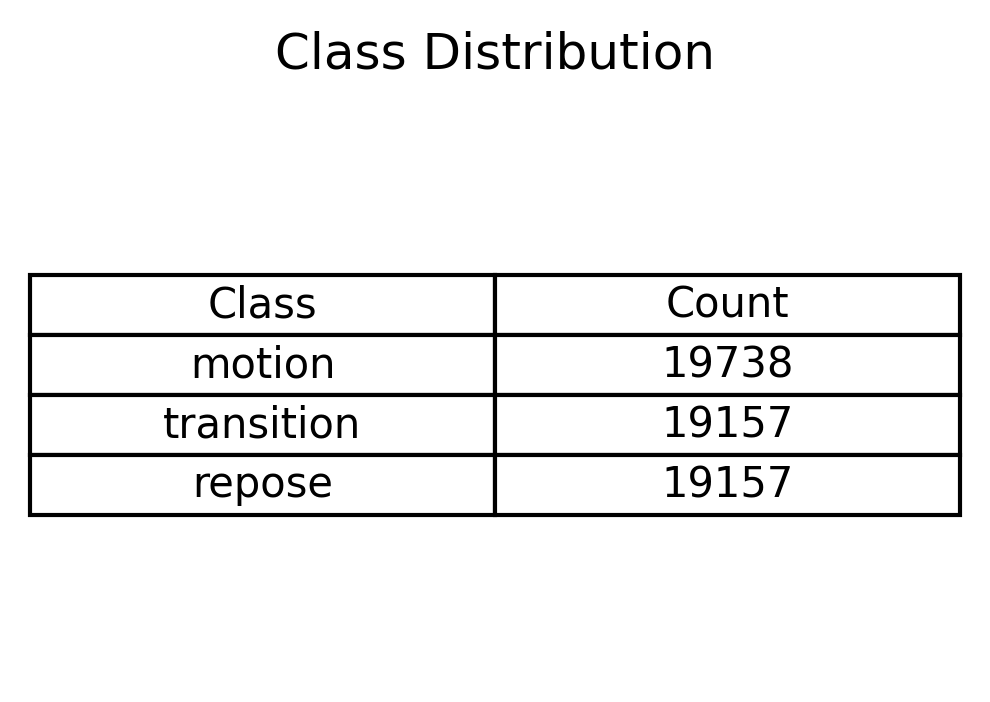



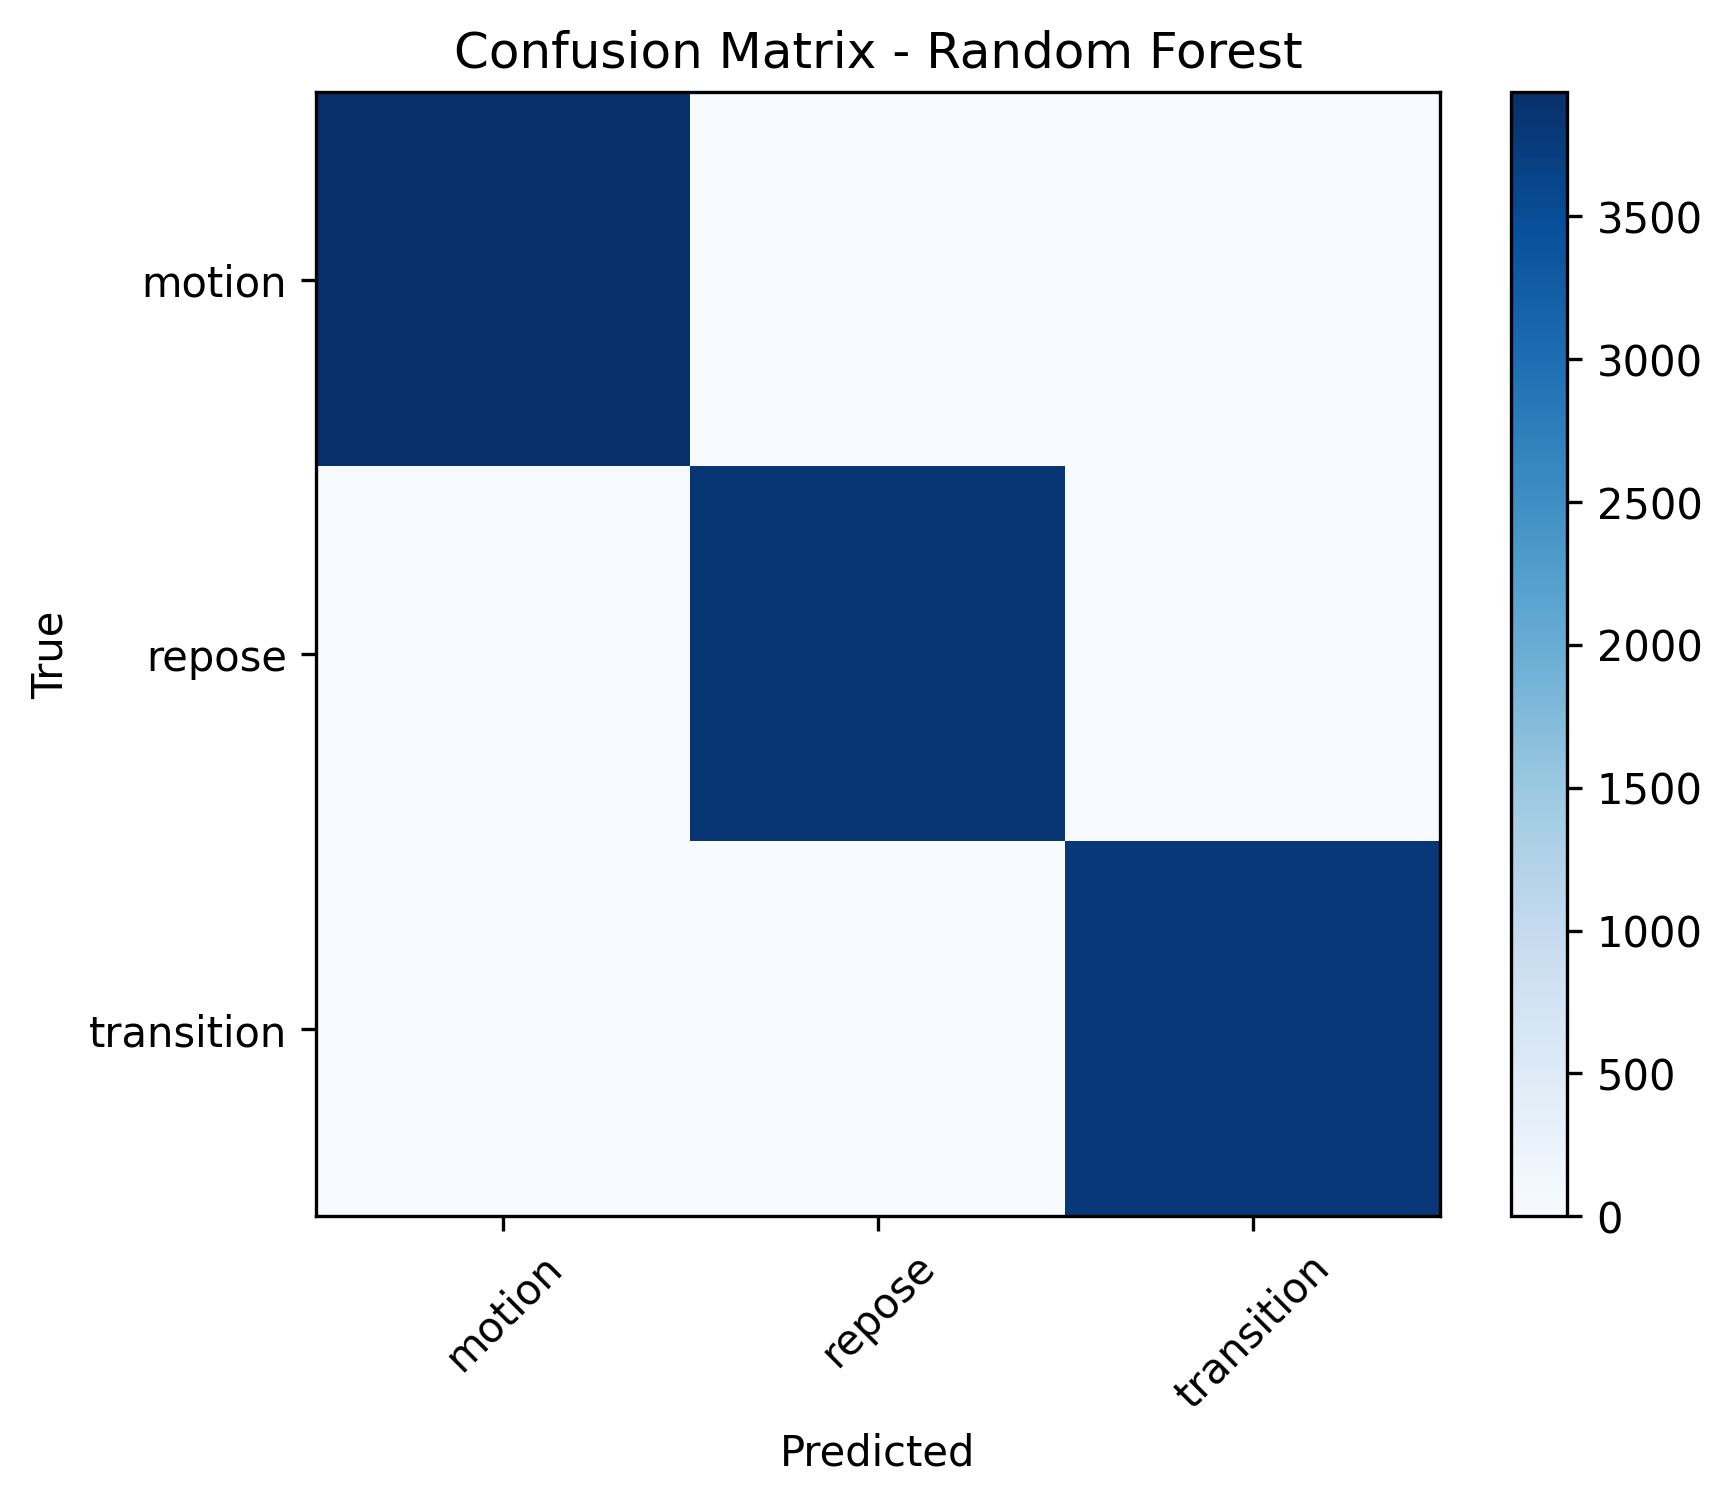

